# TravelMatch — Analyse Exploratoire Complète (EDA)

Visualisations sur l'intégralité des CSV du projet :
**destinations**, **activités**, **météo**, **qualité de vie**, **World Bank**, **dataset ML**.

---
| Section | Contenu |
|---|---|
| 0 | Setup & imports |
| 1 | Chargement & aperçu global |
| 2 | Valeurs manquantes (missingno) |
| 3 | Destinations géographiques |
| 4 | Activités & centres d'intérêt |
| 5 | Météo & températures |
| 6 | Qualité de vie |
| 7 | Données World Bank |
| 8 | Dataset ML principal (data_clean) |
| 9 | Travel Destinations (raw) |
| 10 | Données Touristes |
| 11 | Villes mondiales |
| 12 | Features ML (df_ml) |

## 0 — Setup & Imports

In [51]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_theme(style="whitegrid", palette="husl")

BASE = "../DATA"
print(f"✅ Libraries OK — BASE: {BASE}")

✅ Libraries OK — BASE: ../DATA


## 1 — Chargement & Aperçu Global

In [52]:
dfs = {
    "destinations" : pd.read_csv(f"{BASE}/processed/destinations.csv"),
    "activites"    : pd.read_csv(f"{BASE}/processed/activites.csv"),
    "meteo"        : pd.read_csv(f"{BASE}/processed/meteo.csv"),
    "life_quality" : pd.read_csv(f"{BASE}/processed/life_quality.csv"),
    "worldbank"    : pd.read_csv(f"{BASE}/processed/worldbank.csv"),
    "data_clean"   : pd.read_csv(f"{BASE}/processed/data_clean.csv"),
    "travel_raw"   : pd.read_csv(f"{BASE}/raw/travel_destinations.csv"),
    "touriste"     : pd.read_csv(f"{BASE}/external/donnees_touriste.csv"),
    "villes"       : pd.read_csv(f"{BASE}/processed/villes.csv"),
    "df_ml"        : pd.read_csv(f"{BASE}/processed/df_ml.csv"),
}

dest, act, meteo, lq, wb, clean, raw, tour, villes, ml = dfs.values()

summary = pd.DataFrame(
    [(n, df.shape[0], df.shape[1],
      df.isnull().sum().sum(),
      df.select_dtypes(include="number").shape[1])
     for n, df in dfs.items()],
    columns=["Dataset", "Lignes", "Colonnes", "NaN total", "Cols numériques"]
)
summary

,Dataset,Lignes,Colonnes,NaN total,Cols numériques
0,destinations,104,7,0,2
1,activites,104,11,0,9
2,meteo,1248,7,0,4
3,life_quality,83,11,83,10
4,worldbank,2288,4,157,1
5,data_clean,1008,39,0,35
6,travel_raw,111,4,0,0
7,touriste,41,24,101,22
8,villes,5986,10,1,5
9,df_ml,560,54,0,54


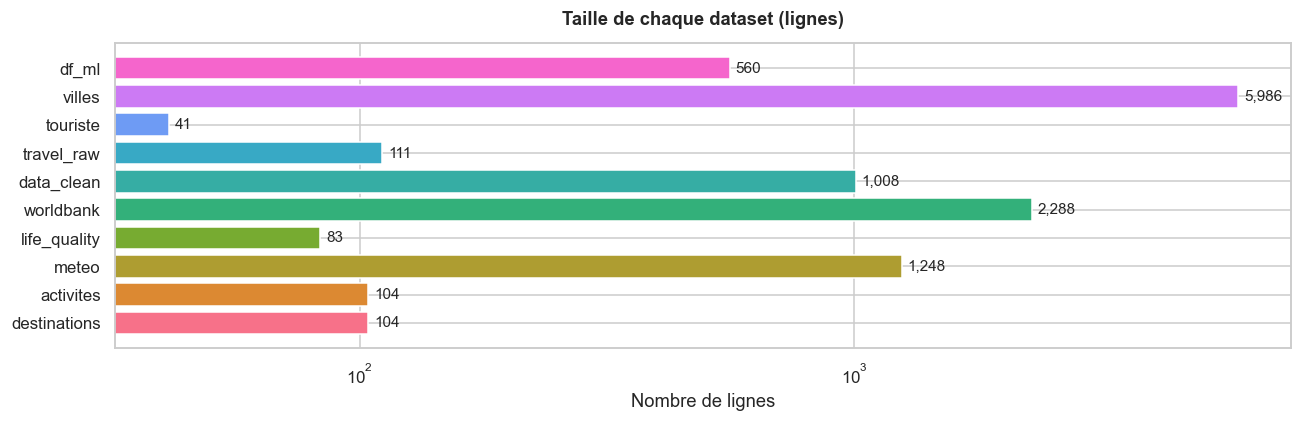

In [53]:
fig, ax = plt.subplots(figsize=(12, 4))
colors = sns.color_palette("husl", len(summary))
bars = ax.barh(summary["Dataset"], summary["Lignes"], color=colors)
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=10)
ax.set_xlabel("Nombre de lignes")
ax.set_title("Taille de chaque dataset (lignes)", fontweight="bold", pad=12)
ax.set_xscale("log")
plt.tight_layout()
plt.show()

## 2 — Valeurs Manquantes (missingno)

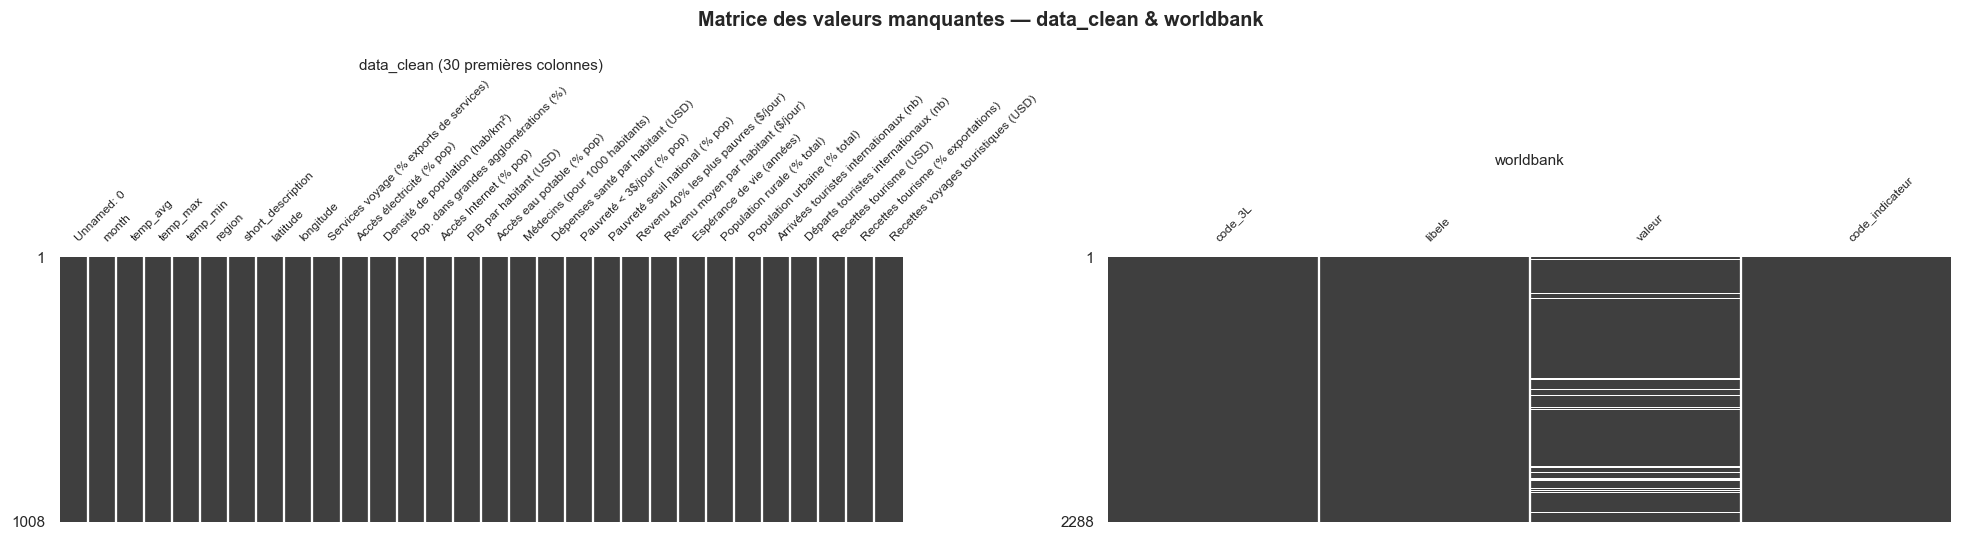

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("Matrice des valeurs manquantes — data_clean & worldbank", fontweight="bold", fontsize=13)
msno.matrix(clean.iloc[:, :30], ax=axes[0], sparkline=False, fontsize=8)
axes[0].set_title("data_clean (30 premières colonnes)", fontsize=10)
msno.matrix(wb, ax=axes[1], sparkline=False, fontsize=8)
axes[1].set_title("worldbank", fontsize=10)
plt.tight_layout()
plt.show()

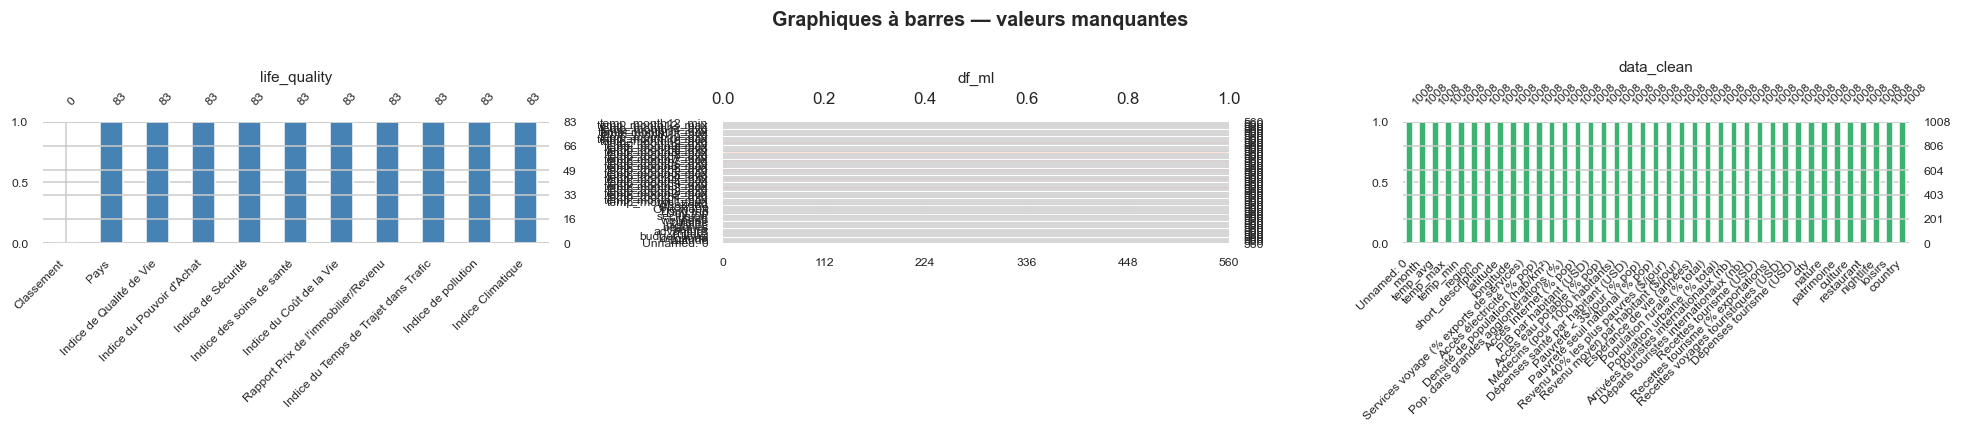

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Graphiques à barres — valeurs manquantes", fontweight="bold", fontsize=13)
msno.bar(lq, ax=axes[0], color="steelblue", fontsize=8)
axes[0].set_title("life_quality", fontsize=10)
msno.bar(ml, ax=axes[1], color="coral", fontsize=8)
axes[1].set_title("df_ml", fontsize=10)
msno.bar(clean, ax=axes[2], color="mediumseagreen", fontsize=8)
axes[2].set_title("data_clean", fontsize=10)
plt.tight_layout()
plt.show()

In [56]:
# Heatmap des corrélations de valeurs manquantes sur data_clean
nan_cols = clean.columns[clean.isnull().sum() > 0].tolist()
if nan_cols:
    fig, ax = plt.subplots(figsize=(10, 6))
    msno.heatmap(clean[nan_cols], ax=ax, fontsize=9)
    ax.set_title("Corrélation des NaN — data_clean", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("✅ data_clean : aucune valeur manquante.")

✅ data_clean : aucune valeur manquante.


## 3 — Destinations Géographiques

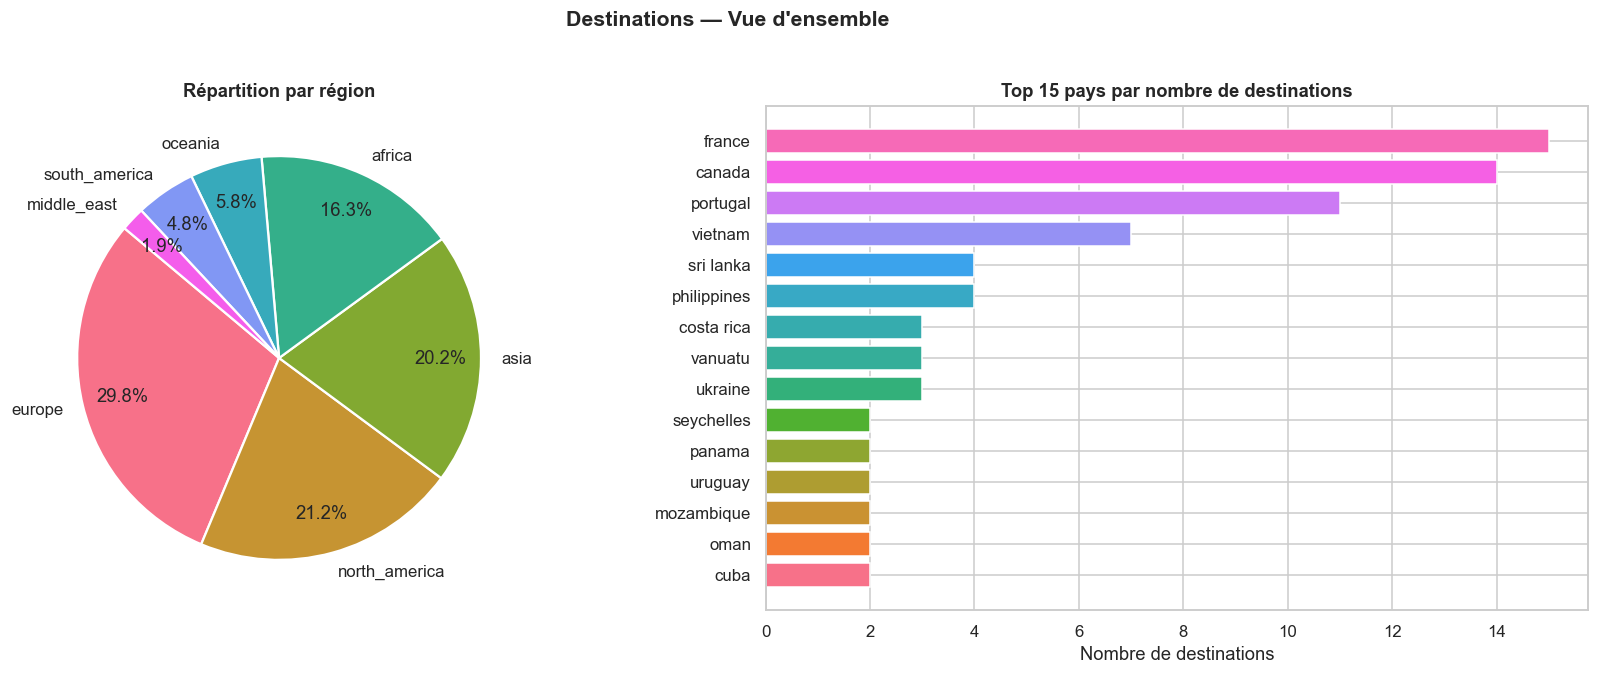

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart par région
region_counts = dest["region"].value_counts()
axes[0].pie(
    region_counts.values,
    labels=region_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("husl", len(region_counts)),
    pctdistance=0.8,
    wedgeprops=dict(linewidth=1.5, edgecolor="white"),
)
axes[0].set_title("Répartition par région", fontweight="bold")

# Bar chart : nombre de destinations par pays (top 15)
top_countries = dest["country"].value_counts().head(15)
axes[1].barh(top_countries.index[::-1], top_countries.values[::-1],
             color=sns.color_palette("husl", 15))
axes[1].set_xlabel("Nombre de destinations")
axes[1].set_title("Top 15 pays par nombre de destinations", fontweight="bold")

plt.suptitle("Destinations — Vue d'ensemble", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

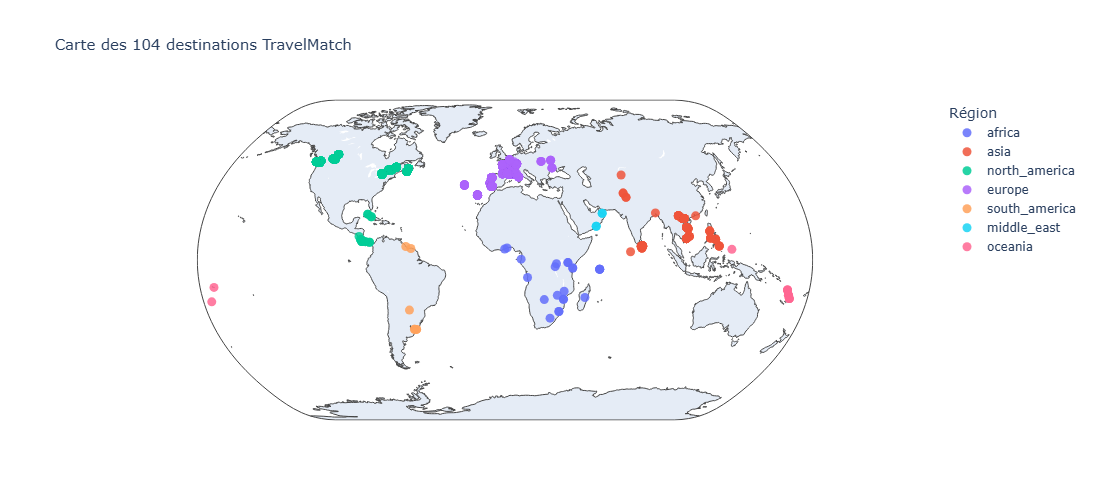

In [58]:
# Carte géographique interactive (Plotly)
dest_map = dest.merge(act[["code_3L", "nature", "culture", "nightlife"]], on="code_3L", how="left")

fig = px.scatter_geo(
    dest_map,
    lat="latitude",
    lon="longitude",
    color="region",
    hover_name="City",
    hover_data={"country": True, "latitude": False, "longitude": False},
    title="Carte des 104 destinations TravelMatch",
    projection="natural earth",
    height=500,
)
fig.update_traces(marker=dict(size=9, opacity=0.85))
fig.update_layout(title_font_size=15, legend_title_text="Région")
fig.show()

## 4 — Activités & Centres d'Intérêt

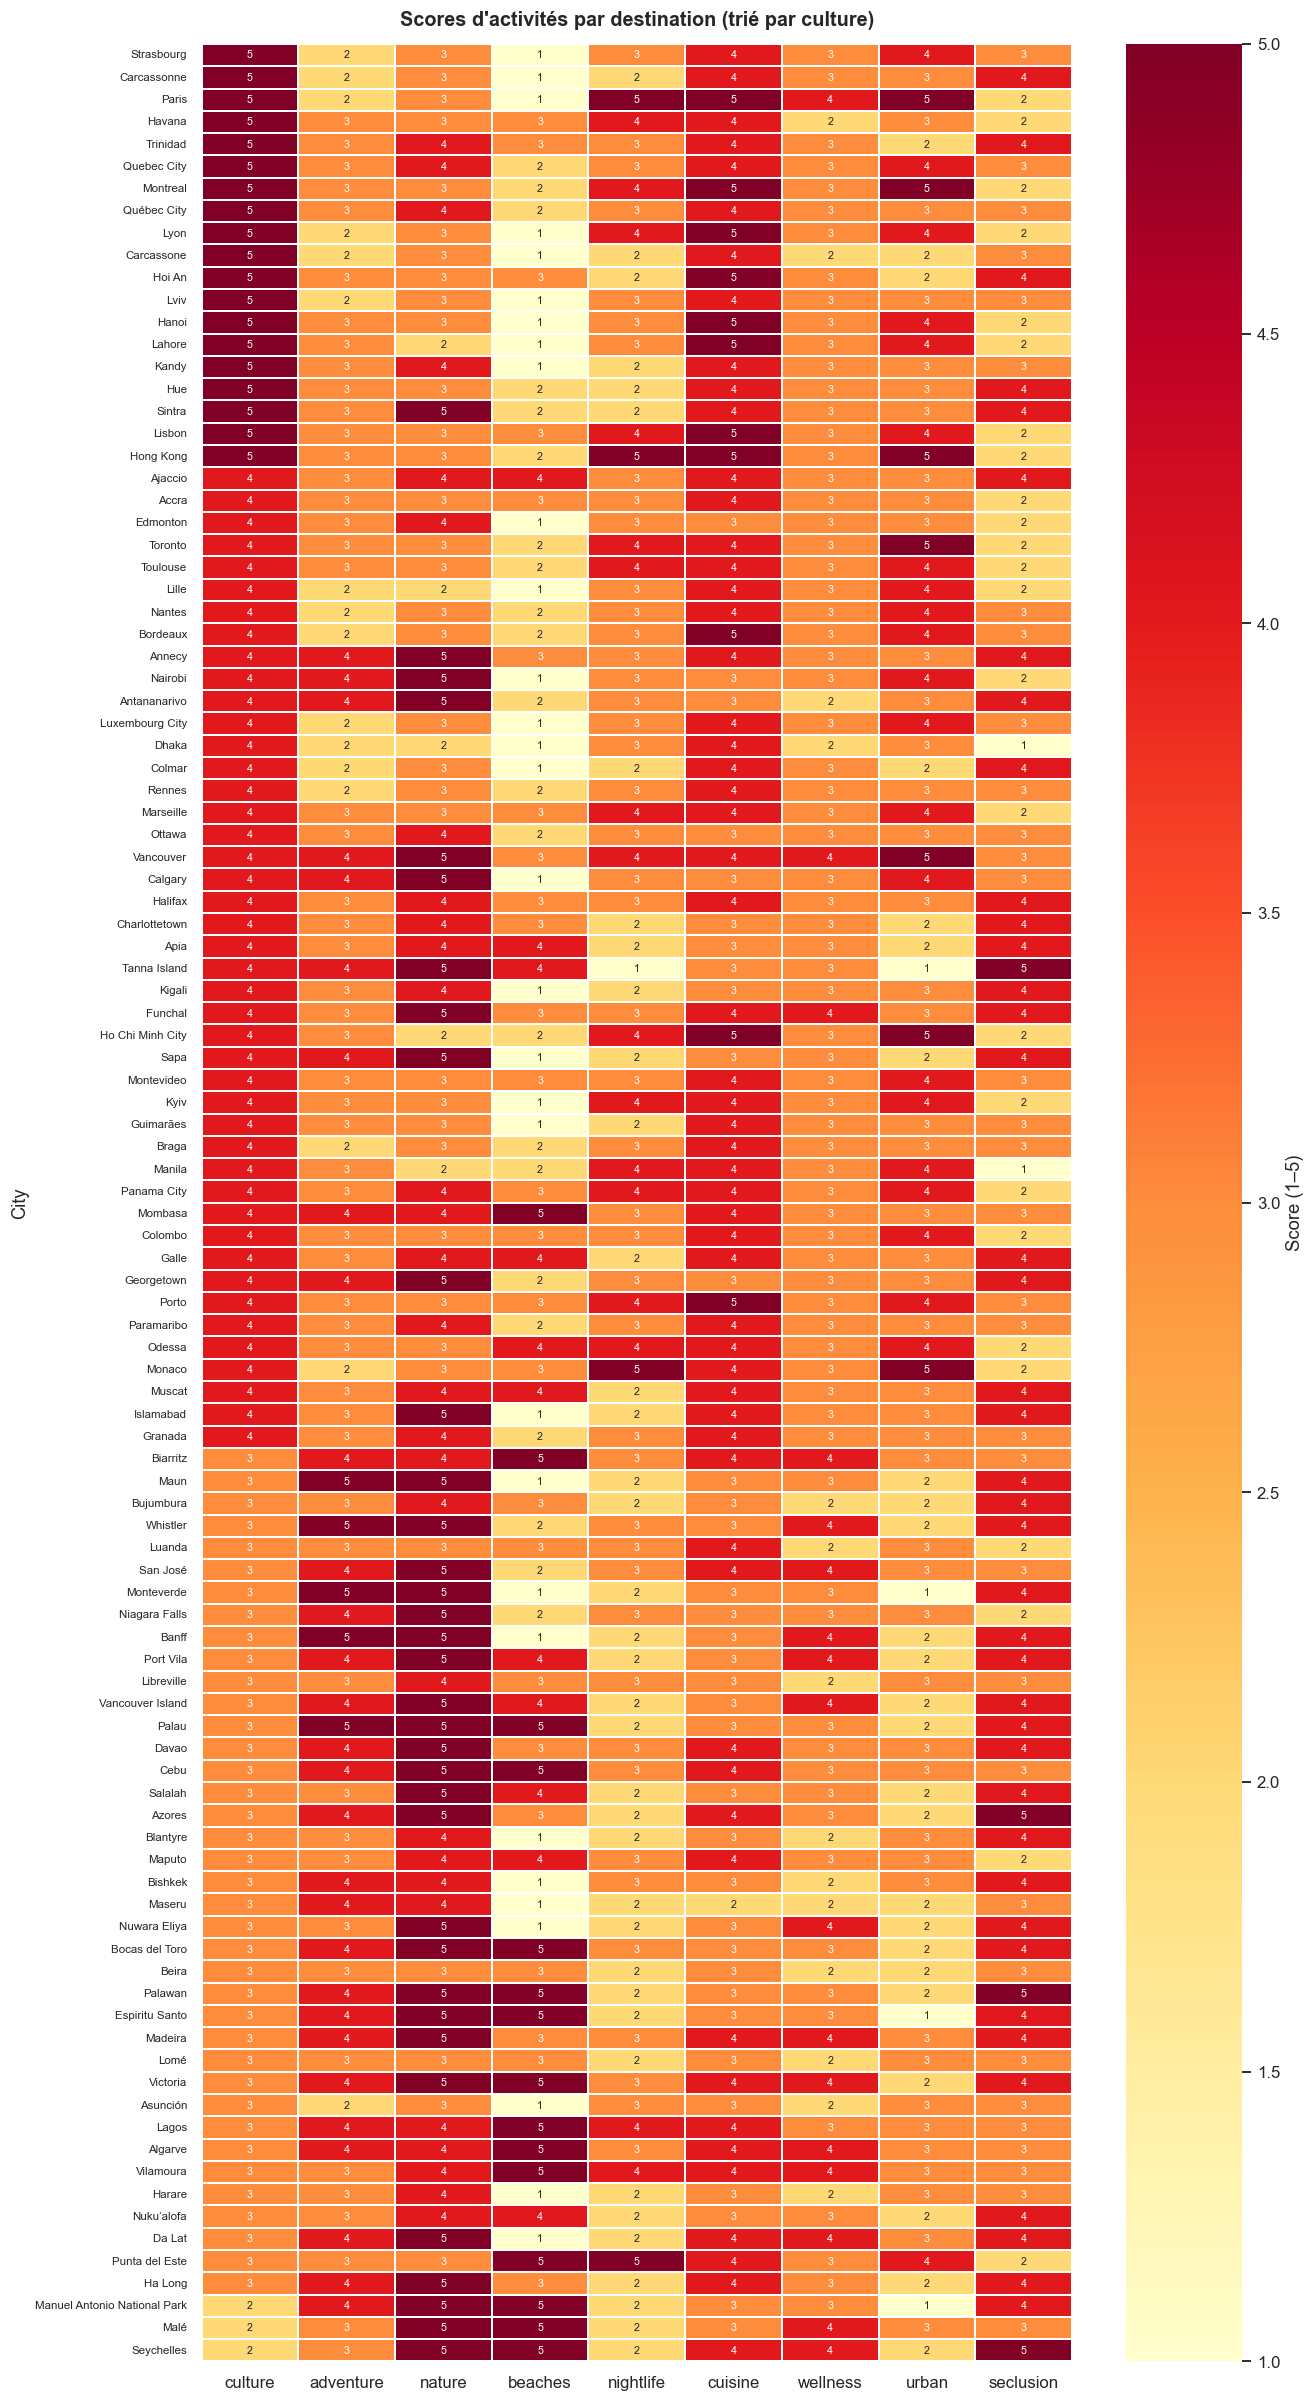

In [59]:
ACT_COLS = ["culture", "adventure", "nature", "beaches", "nightlife",
            "cuisine", "wellness", "urban", "seclusion"]

# Heatmap : villes × activités
act_sorted = act.set_index("City")[ACT_COLS].sort_values("culture", ascending=False)

fig, ax = plt.subplots(figsize=(12, 22))
sns.heatmap(
    act_sorted,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 7},
    ax=ax,
    cbar_kws={"label": "Score (1–5)"},
)
ax.set_title("Scores d'activités par destination (trié par culture)",
             fontweight="bold", fontsize=13, pad=12)
ax.set_xlabel("")
ax.tick_params(axis="y", labelsize=7.5)
plt.tight_layout()
plt.show()

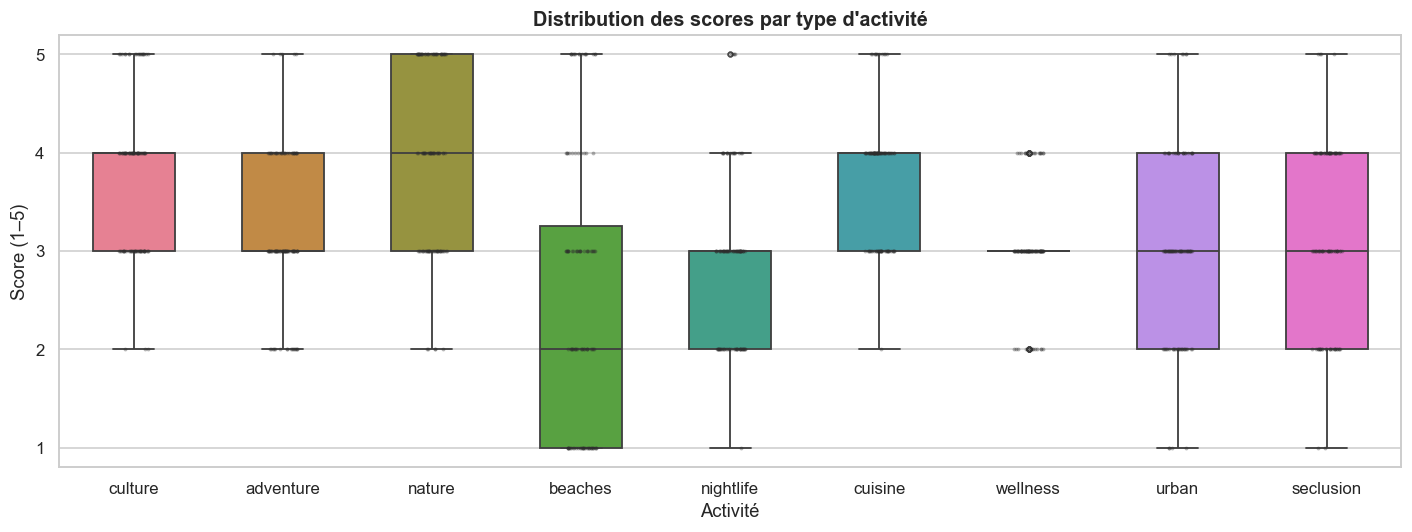

In [60]:
# Box plots des distributions par activité
act_long = act[ACT_COLS].melt(var_name="Activité", value_name="Score")

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(
    data=act_long, x="Activité", y="Score",
    palette="husl", width=0.55, linewidth=1.2,
    flierprops=dict(marker="o", markersize=3, alpha=0.5),
    ax=ax,
)
sns.stripplot(
    data=act_long, x="Activité", y="Score",
    color="#2d2d2d", size=2.5, alpha=0.35, jitter=True, ax=ax,
)
ax.set_title("Distribution des scores par type d'activité", fontweight="bold", fontsize=13)
ax.set_yticks(range(1, 6))
ax.set_ylabel("Score (1–5)")
plt.tight_layout()
plt.show()

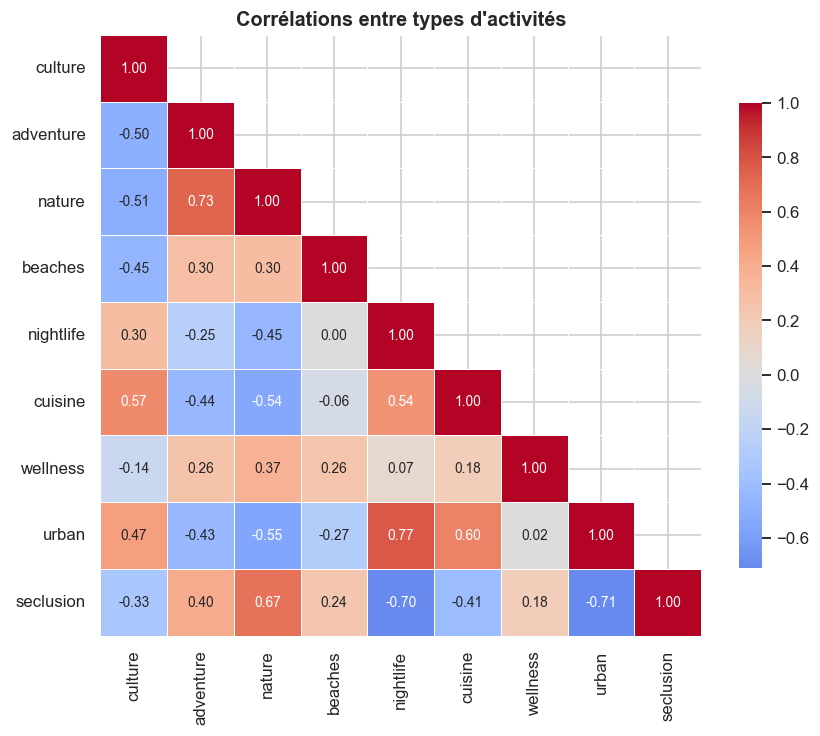

In [61]:
# Corrélation entre activités
corr_act = act[ACT_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr_act, dtype=bool), k=1)
sns.heatmap(
    corr_act, mask=mask,
    cmap="coolwarm", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    linewidths=0.5, square=True,
    cbar_kws={"shrink": 0.7},
    ax=ax,
)
ax.set_title("Corrélations entre types d'activités", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

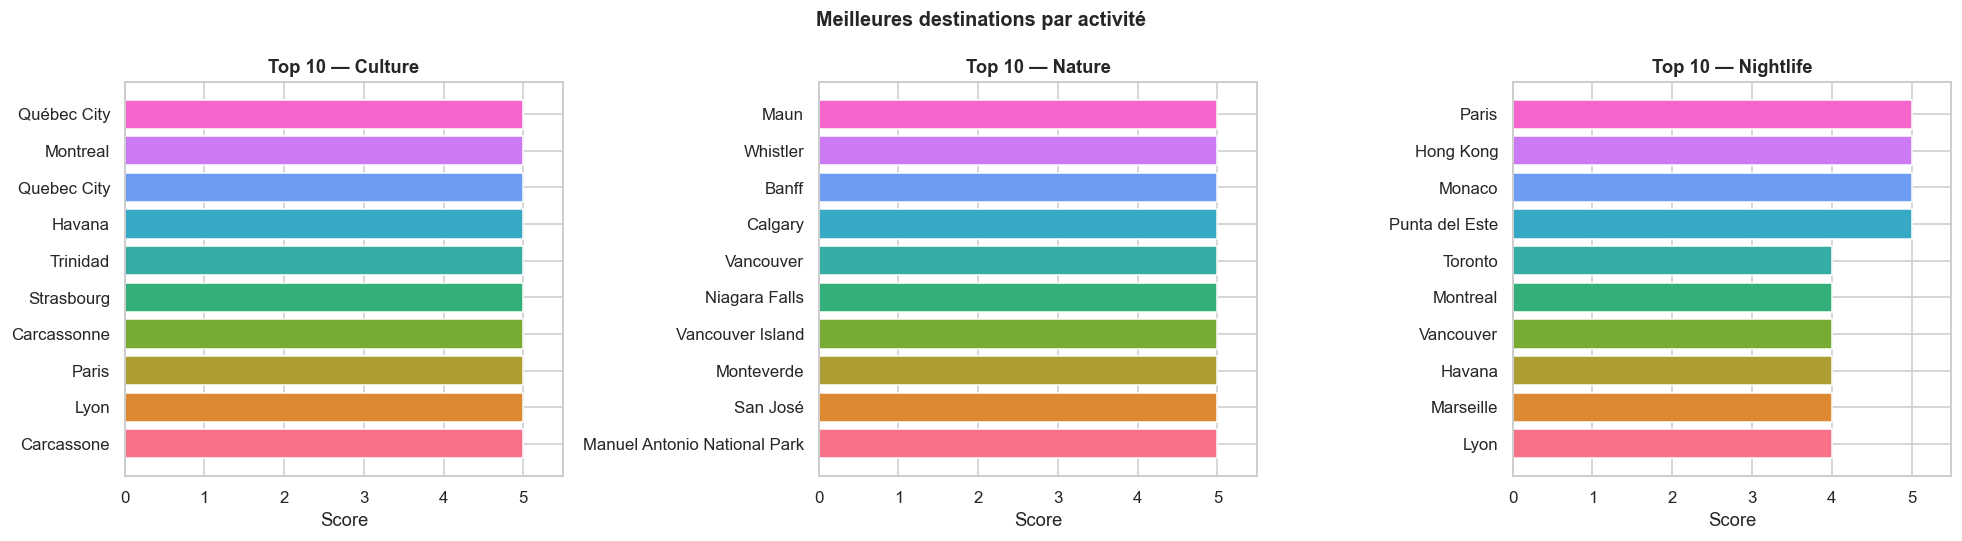

In [62]:
# Top 10 destinations pour 3 activités clés
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["culture", "nature", "nightlife"]):
    top = act.nlargest(10, col).set_index("City")[col]
    colors = sns.color_palette("husl", 10)
    ax.barh(top.index[::-1], top.values[::-1], color=colors)
    ax.set_xlim(0, 5.5)
    ax.set_xlabel("Score")
    ax.set_title(f"Top 10 — {col.capitalize()}", fontweight="bold")
plt.suptitle("Meilleures destinations par activité", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

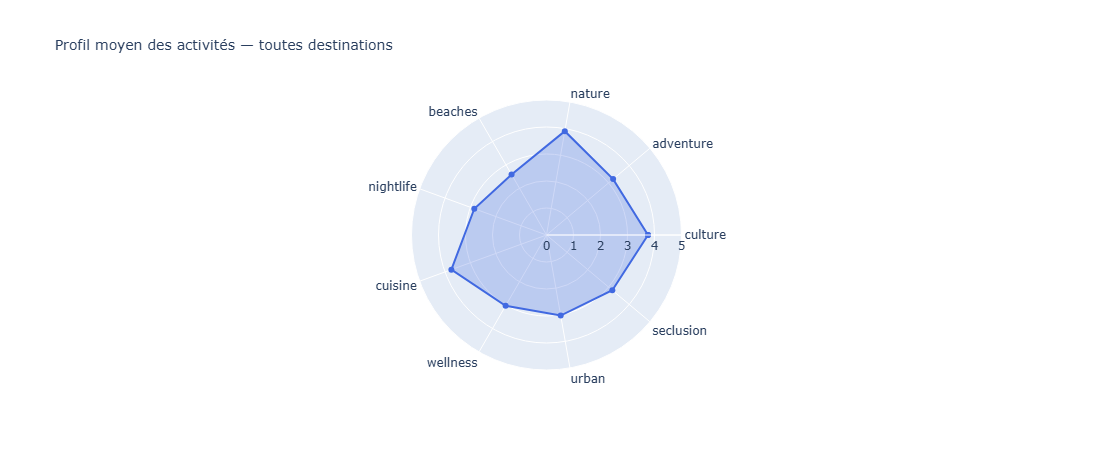

In [63]:
# Scores moyens par activité — radar chart (Plotly)
means = act[ACT_COLS].mean().reset_index()
means.columns = ["activite", "score"]

fig = go.Figure(go.Scatterpolar(
    r=means["score"].tolist() + [means["score"].iloc[0]],
    theta=means["activite"].tolist() + [means["activite"].iloc[0]],
    fill="toself",
    name="Score moyen",
    line_color="royalblue",
    fillcolor="rgba(65, 105, 225, 0.25)",
))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 5])),
    title="Profil moyen des activités — toutes destinations",
    title_font_size=14,
    height=450,
)
fig.show()

## 5 — Météo & Températures

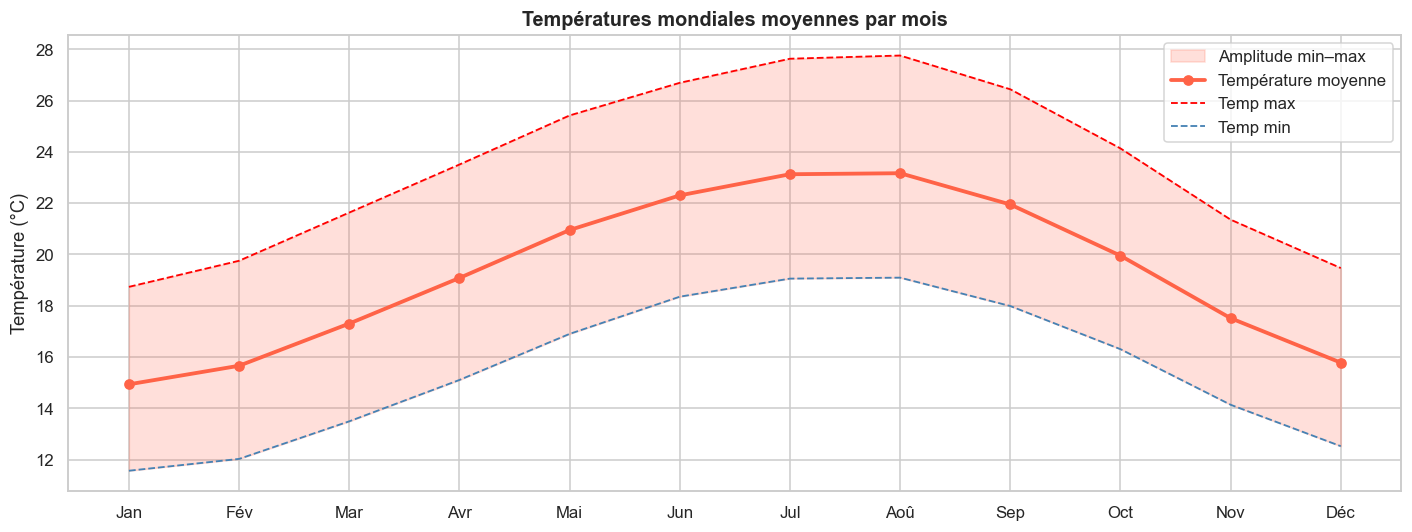

In [64]:
# Températures moyennes mondiales par mois (toutes villes confondues)
monthly_mean = meteo.groupby("month")[["temp_avg", "temp_max", "temp_min"]].mean()
MONTH_LABELS = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(range(1, 13), monthly_mean["temp_min"], monthly_mean["temp_max"],
                alpha=0.2, color="tomato", label="Amplitude min–max")
ax.plot(range(1, 13), monthly_mean["temp_avg"], color="tomato",
        marker="o", linewidth=2.5, label="Température moyenne")
ax.plot(range(1, 13), monthly_mean["temp_max"], color="red",
        linestyle="--", linewidth=1.2, label="Temp max")
ax.plot(range(1, 13), monthly_mean["temp_min"], color="steelblue",
        linestyle="--", linewidth=1.2, label="Temp min")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_ylabel("Température (°C)")
ax.set_title("Températures mondiales moyennes par mois", fontweight="bold", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

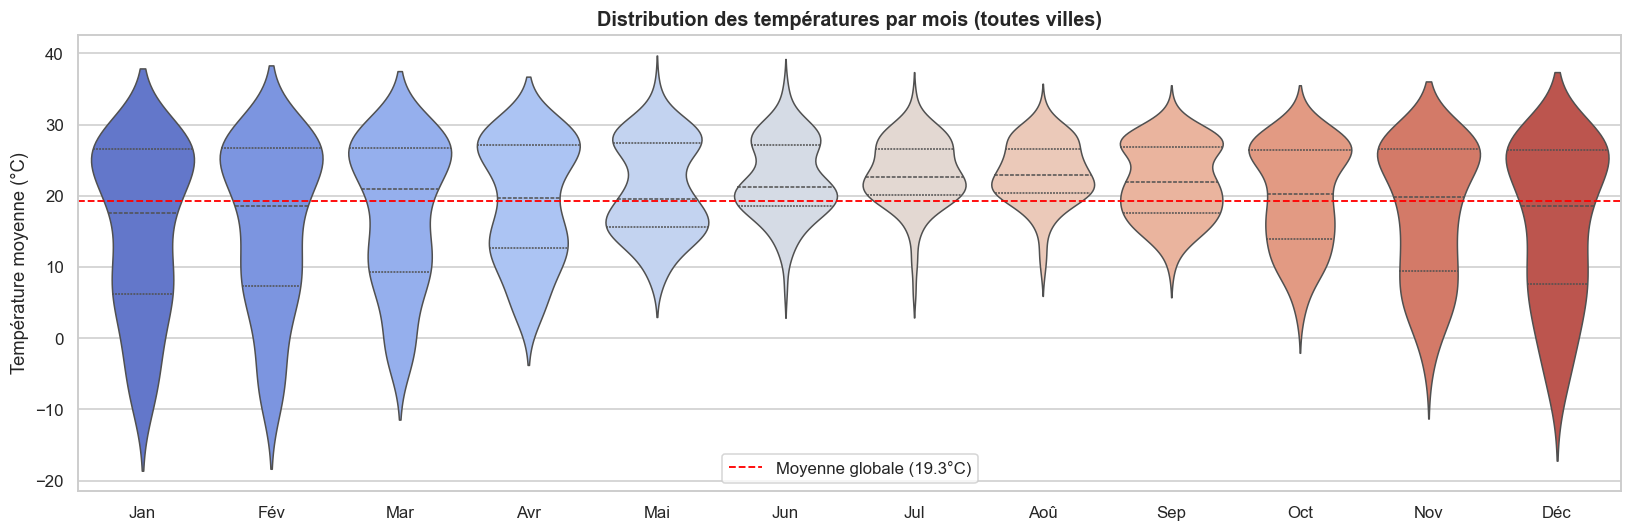

In [65]:
# Violin plots : distribution des temp_avg par mois
fig, ax = plt.subplots(figsize=(15, 5))
sns.violinplot(
    data=meteo, x="month", y="temp_avg",
    palette="coolwarm", inner="quartile", linewidth=1, ax=ax,
)
ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_LABELS)
ax.set_xlabel("")
ax.set_ylabel("Température moyenne (°C)")
ax.set_title("Distribution des températures par mois (toutes villes)",
             fontweight="bold", fontsize=13)
ax.axhline(meteo["temp_avg"].mean(), color="red", linestyle="--",
           linewidth=1.2, label=f"Moyenne globale ({meteo['temp_avg'].mean():.1f}°C)")
ax.legend()
plt.tight_layout()
plt.show()

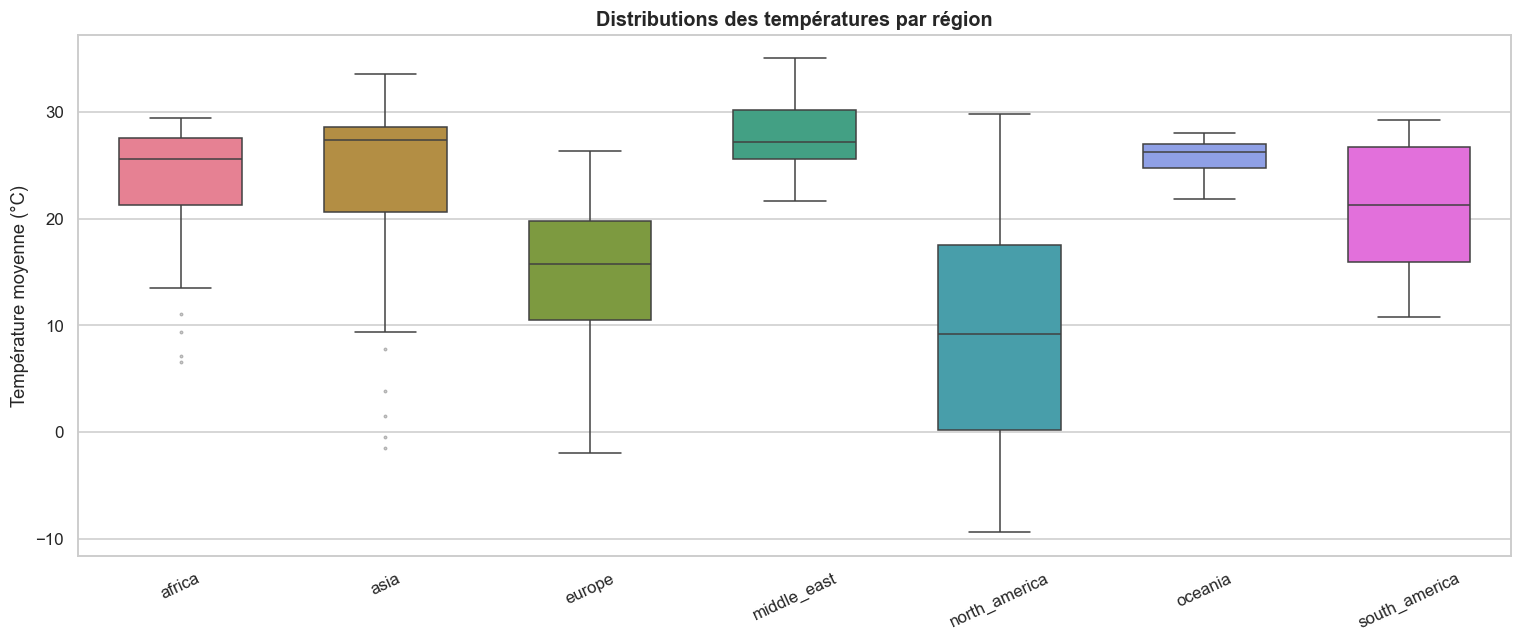

In [66]:
# Températures par région (merge meteo × destinations)
meteo_dest = meteo.merge(dest[["code_3L", "region"]], on="code_3L", how="left")

fig, ax = plt.subplots(figsize=(14, 6))
regions = sorted(meteo_dest["region"].dropna().unique())
palette = sns.color_palette("husl", len(regions))
sns.boxplot(
    data=meteo_dest, x="region", y="temp_avg",
    palette=palette, width=0.6, order=regions,
    flierprops=dict(marker=".", markersize=3, alpha=0.4), ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Température moyenne (°C)")
ax.set_title("Distributions des températures par région", fontweight="bold", fontsize=13)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

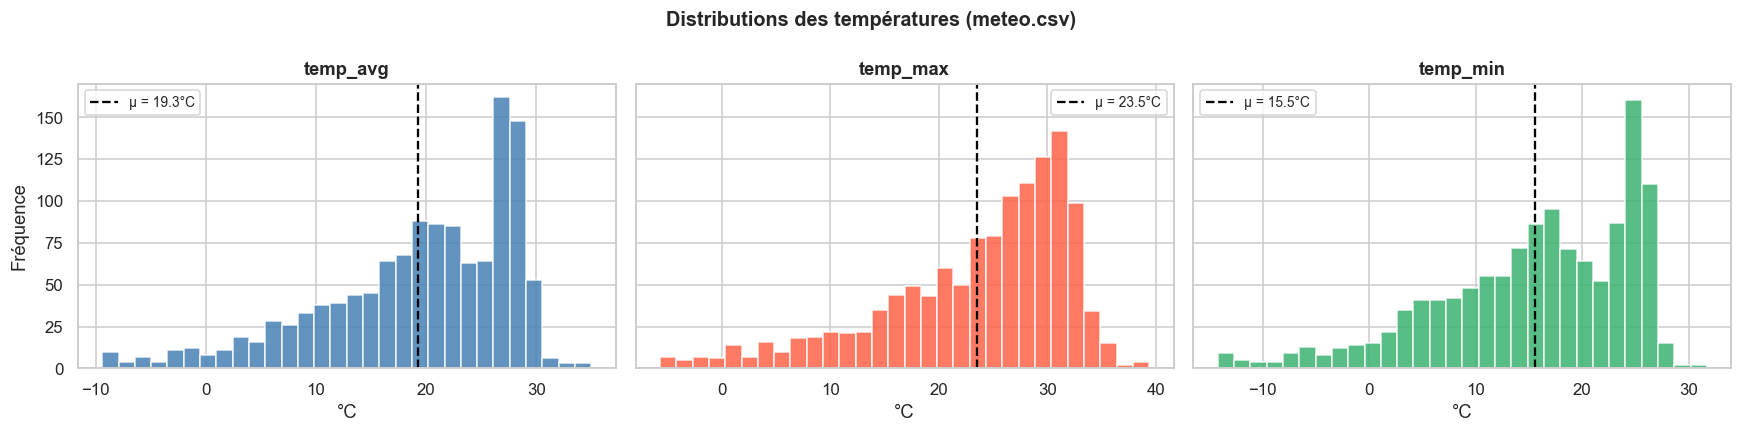

In [67]:
# Histogrammes : distributions des 3 mesures de température
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, col, color in zip(axes,
                          ["temp_avg", "temp_max", "temp_min"],
                          ["steelblue", "tomato", "mediumseagreen"]):
    ax.hist(meteo[col].dropna(), bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(meteo[col].mean(), color="black", linestyle="--",
               linewidth=1.5, label=f"μ = {meteo[col].mean():.1f}°C")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("°C")
    ax.legend(fontsize=9)
axes[0].set_ylabel("Fréquence")
plt.suptitle("Distributions des températures (meteo.csv)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

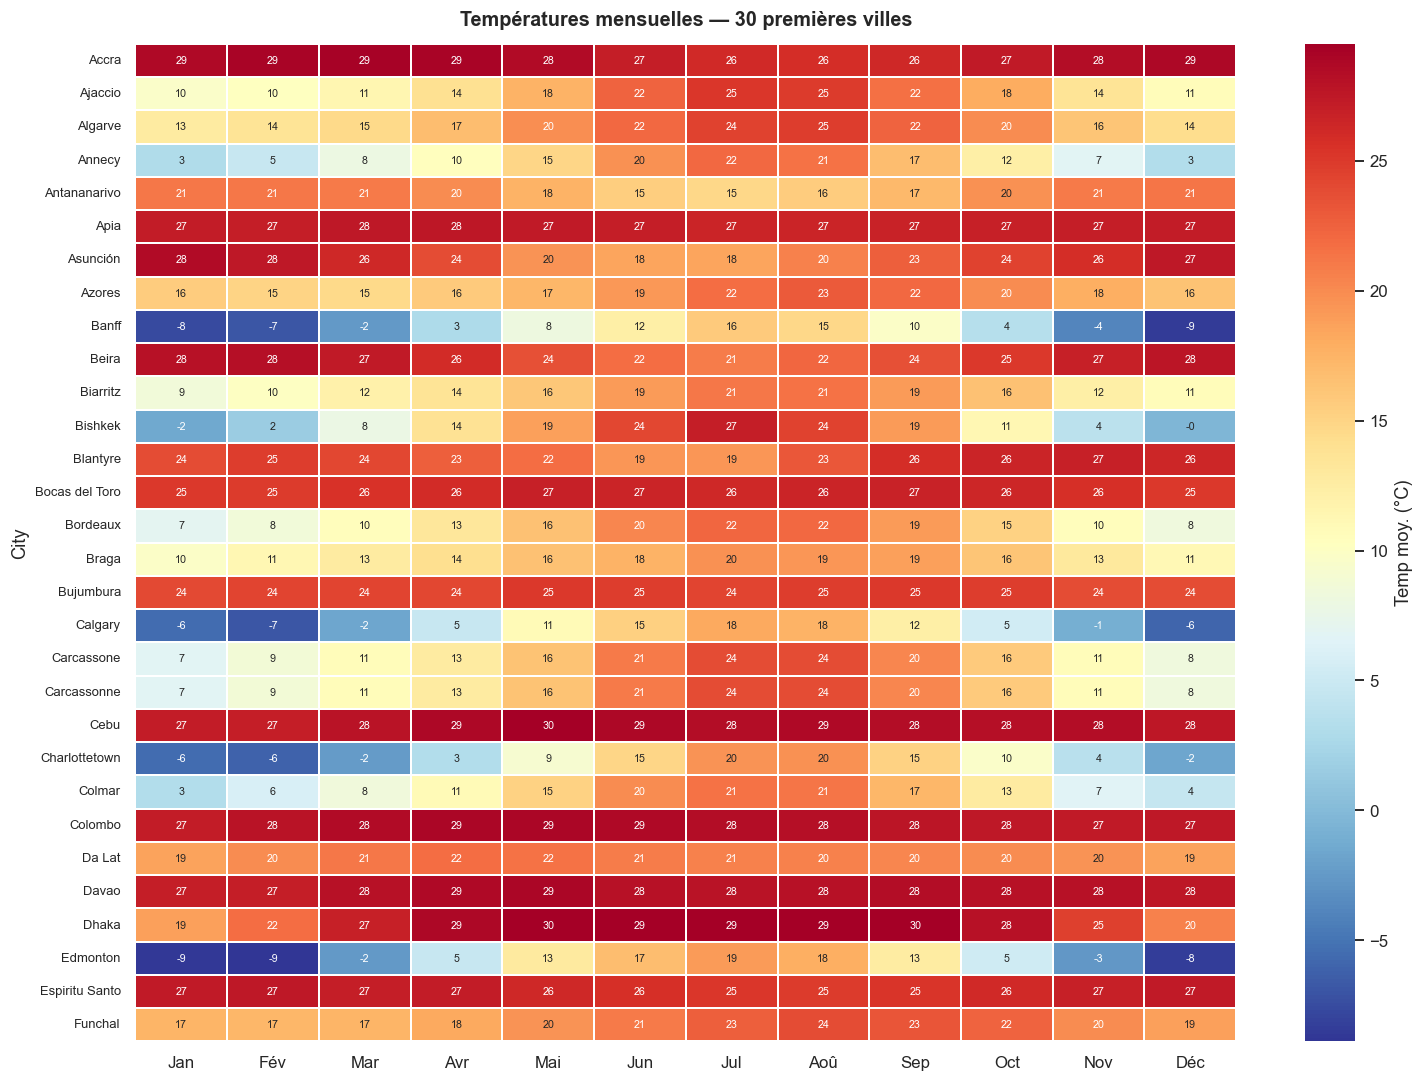

In [68]:
# Heatmap des températures mensuelles par ville (top 30 villes, pivotée)
pivot_temp = (
    meteo.pivot_table(index="City", columns="month", values="temp_avg")
    .dropna(thresh=10)
    .iloc[:30]
)
pivot_temp.columns = MONTH_LABELS[:len(pivot_temp.columns)]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot_temp, cmap="RdYlBu_r",
    linewidths=0.3, linecolor="white",
    annot=True, fmt=".0f", annot_kws={"size": 7},
    cbar_kws={"label": "Temp moy. (°C)"},
    ax=ax,
)
ax.set_title("Températures mensuelles — 30 premières villes",
             fontweight="bold", fontsize=13, pad=12)
ax.set_xlabel("")
ax.tick_params(axis="y", labelsize=8.5)
plt.tight_layout()
plt.show()

## 6 — Qualité de Vie

In [69]:
# Renommer les colonnes pour lisibilité
lq_cols = lq.columns.tolist()
print("Colonnes life_quality:", lq_cols)
lq.head(3)

Colonnes life_quality: ['Classement', 'Pays', 'Indice de Qualité de Vie', "Indice du Pouvoir d'Achat", 'Indice de Sécurité', 'Indice des soins de santé', 'Indice du Coût de la Vie', "Rapport Prix de l'immobilier/Revenu", 'Indice du Temps de Trajet dans Trafic', 'Indice de pollution', 'Indice Climatique']


,Classement,Pays,Indice de Qualité de Vie,Indice du Pouvoir d'Achat,Indice de Sécurité,Indice des soins de santé,Indice du Coût de la Vie,Rapport Prix de l'immobilier/Revenu,Indice du Temps de Trajet dans Trafic,Indice de pollution,Indice Climatique
0,NaN,Luxembourg,219.32,182.53,65.72,75.33,62.43,8.88,27.18,23.27,82.62
1,NaN,Pays-Bas,207.48,124.91,73.58,79.28,63.12,7.69,23.48,21.38,87.01
2,NaN,Danemark,205.57,127.20,73.89,78.47,72.27,6.58,27.81,20.75,83.74


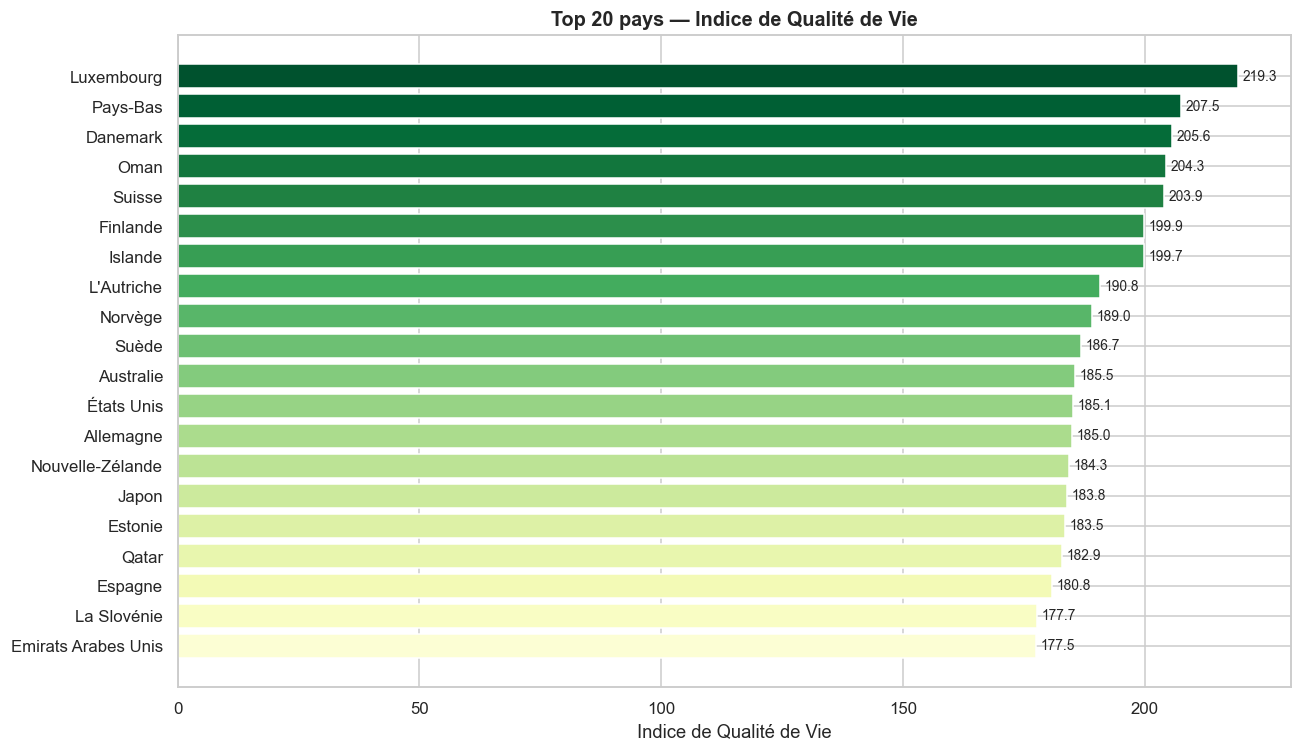

In [70]:
# Identifier les colonnes clés (1er col = classement, 2e = pays, reste = indices)
rank_col, pays_col = lq_cols[0], lq_cols[1]
idx_cols = [c for c in lq_cols[2:] if lq[c].dtype in [np.float64, np.int64] or
            pd.to_numeric(lq[c], errors="coerce").notna().sum() > 40]

# Conversion numérique propre
lq_clean = lq.copy()
for c in idx_cols:
    lq_clean[c] = pd.to_numeric(lq_clean[c], errors="coerce")
lq_clean = lq_clean.dropna(subset=idx_cols[:1])

# Bar chart : Top 20 pays par qualité de vie
qol_col = idx_cols[0]
top20 = lq_clean.nlargest(20, qol_col)

fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette("YlGn", 20)[::-1]
ax.barh(top20[pays_col][::-1], top20[qol_col][::-1], color=colors[::-1])
ax.set_xlabel("Indice de Qualité de Vie")
ax.set_title(f"Top 20 pays — {qol_col}", fontweight="bold", fontsize=13)
ax.bar_label(ax.containers[0], fmt="%.1f", padding=3, fontsize=9)
plt.tight_layout()
plt.show()

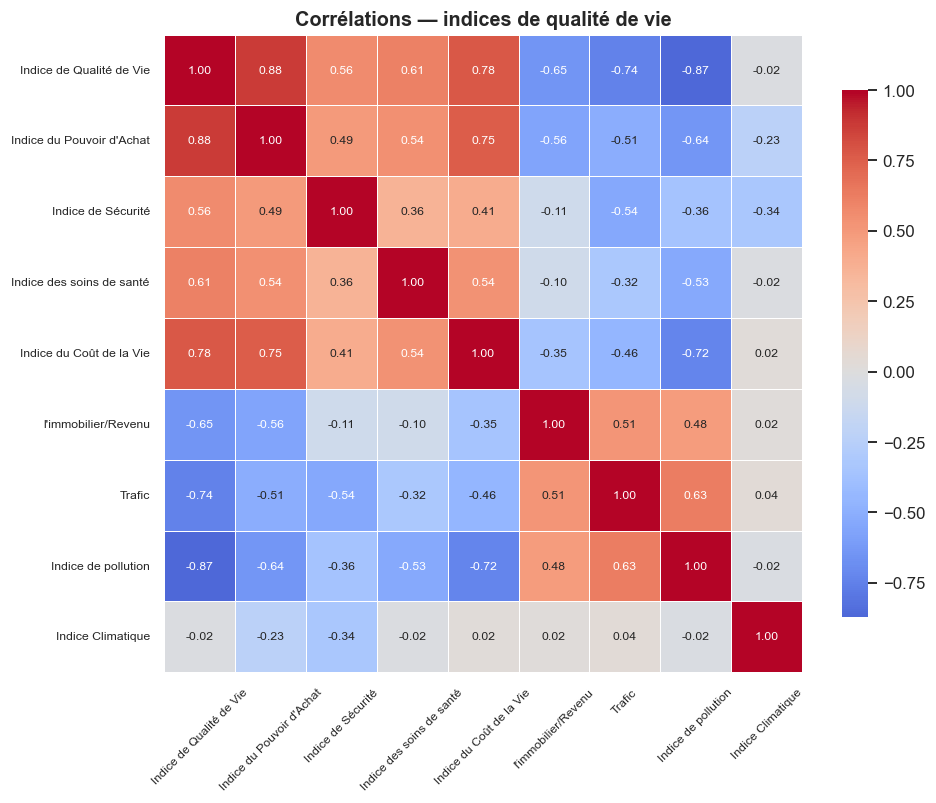

In [71]:
# Corrélation entre tous les indices de qualité de vie
corr_lq = lq_clean[idx_cols].corr()

short_labels = [c.split(" ")[-1] if len(c) > 25 else c for c in idx_cols]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    corr_lq,
    xticklabels=short_labels, yticklabels=short_labels,
    cmap="coolwarm", center=0, annot=True, fmt=".2f",
    annot_kws={"size": 8}, linewidths=0.5, square=True,
    cbar_kws={"shrink": 0.7}, ax=ax,
)
ax.set_title("Corrélations — indices de qualité de vie", fontweight="bold", fontsize=13)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

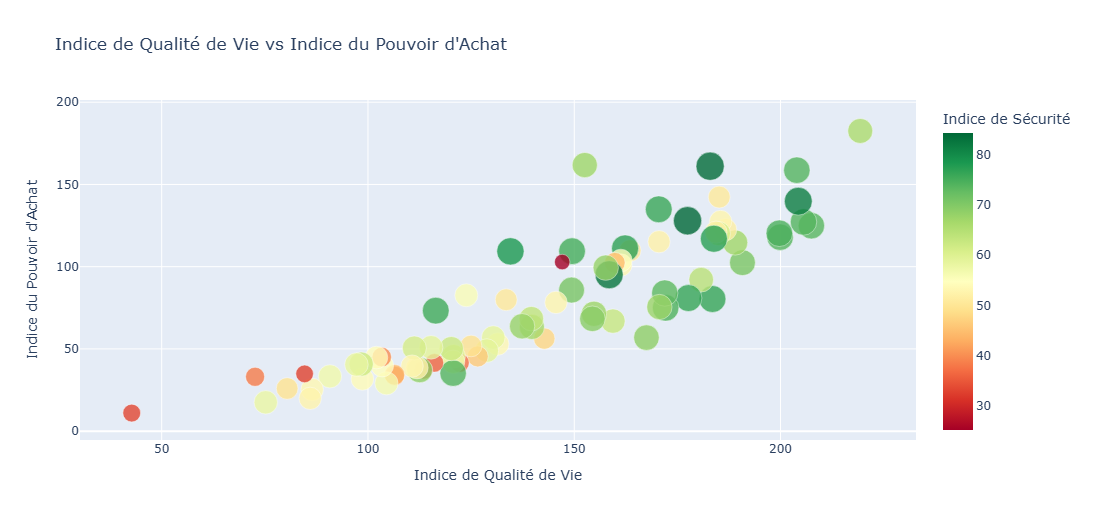

In [72]:
# Scatter plot interactif : 2 premiers indices
if len(idx_cols) >= 3:
    x_col, y_col, s_col = idx_cols[0], idx_cols[1], idx_cols[2]
    fig = px.scatter(
        lq_clean.dropna(subset=[x_col, y_col]),
        x=x_col, y=y_col,
        hover_name=pays_col,
        size=s_col if lq_clean[s_col].min() > 0 else None,
        color=s_col,
        color_continuous_scale="RdYlGn",
        title=f"{x_col} vs {y_col}",
        height=520,
    )
    fig.update_traces(marker=dict(opacity=0.8, line=dict(width=0.5, color="white")))
    fig.show()

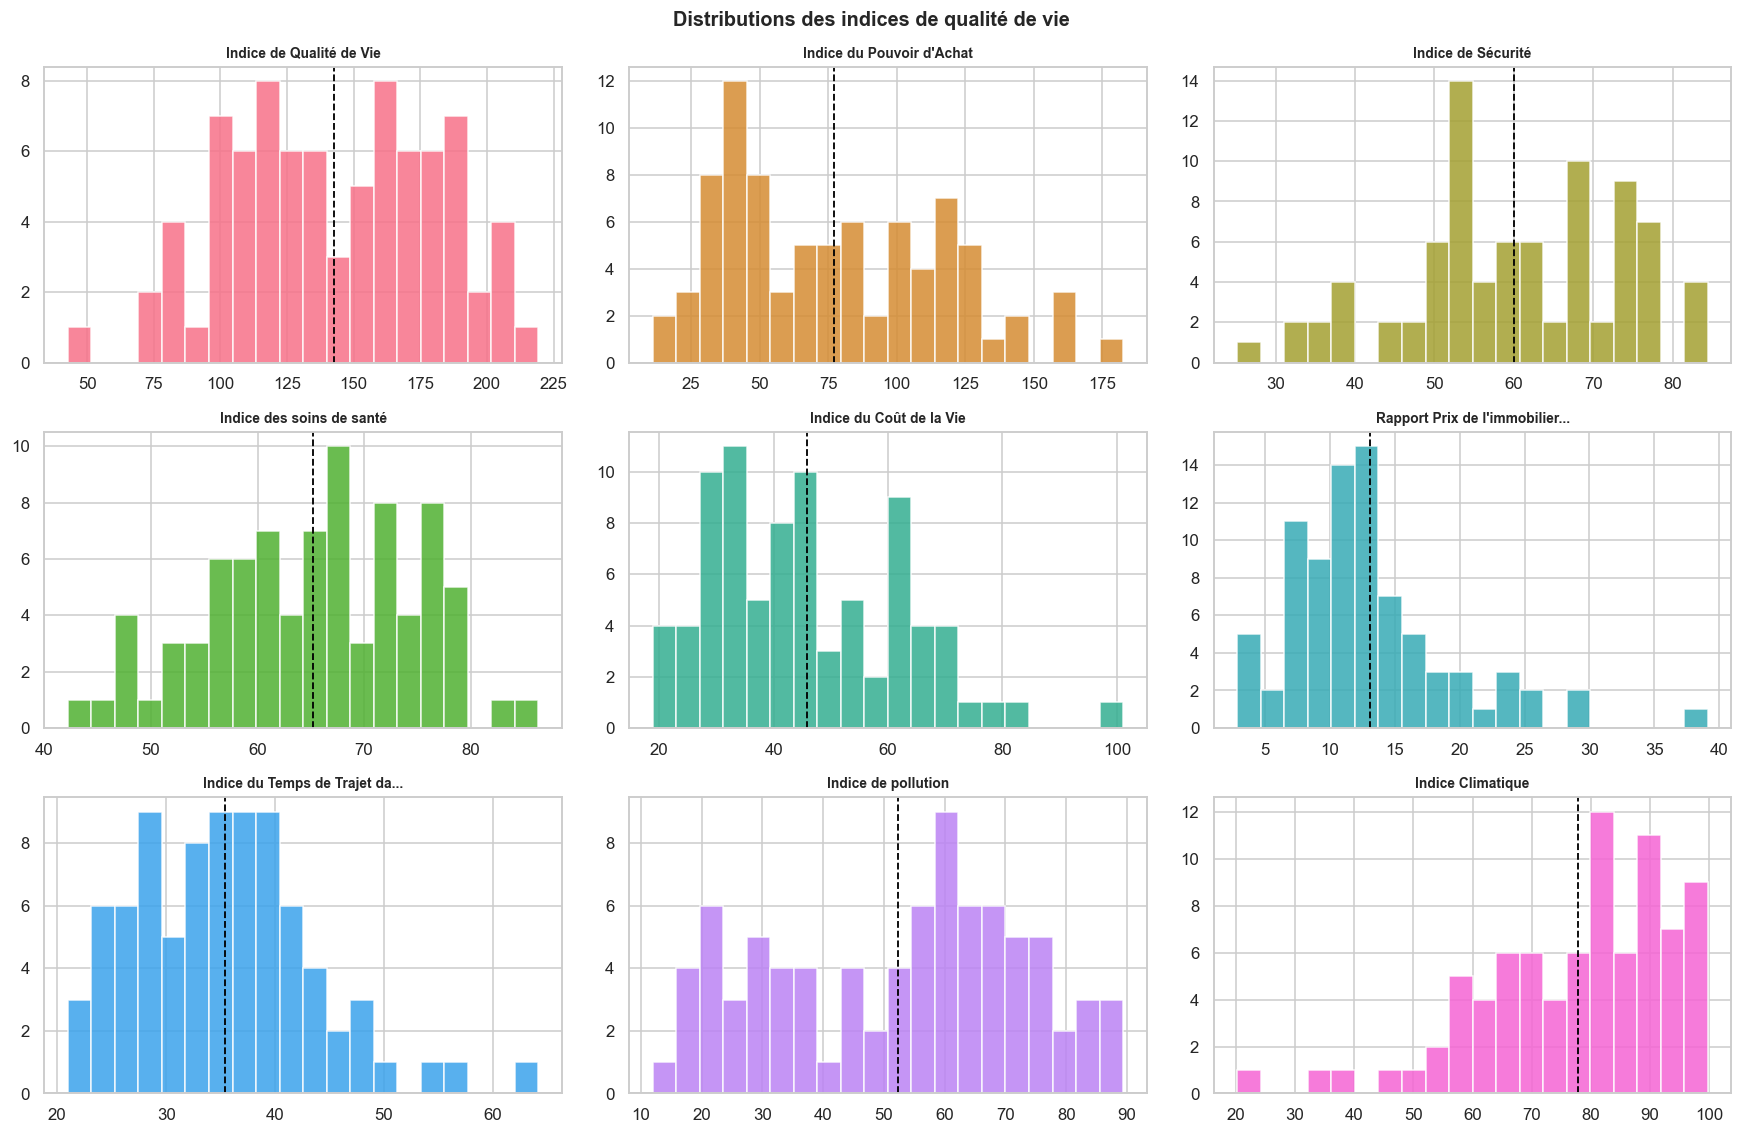

In [73]:
# Histogrammes de tous les indices
n = len(idx_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
palette = sns.color_palette("husl", n)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()
for i, (col, color) in enumerate(zip(idx_cols, palette)):
    data = lq_clean[col].dropna()
    axes[i].hist(data, bins=20, color=color, edgecolor="white", alpha=0.85)
    axes[i].axvline(data.mean(), color="black", linestyle="--", linewidth=1.2)
    short = col if len(col) <= 30 else col[:28] + "..."
    axes[i].set_title(short, fontsize=9, fontweight="bold")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Distributions des indices de qualité de vie", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7 — Données World Bank

In [74]:
print("Colonnes worldbank:")
print(wb.dtypes.to_string())
wb.head(3)

Colonnes worldbank:
code_3L             object
libele              object
valeur             float64
code_indicateur     object


,code_3L,libele,valeur,code_indicateur
0,AGO,Services voyage (% exports de services),9.923331,BX.GSR.TRVL.ZS
1,BDI,Services voyage (% exports de services),2.372476,BX.GSR.TRVL.ZS
2,BGD,Services voyage (% exports de services),7.113293,BX.GSR.TRVL.ZS


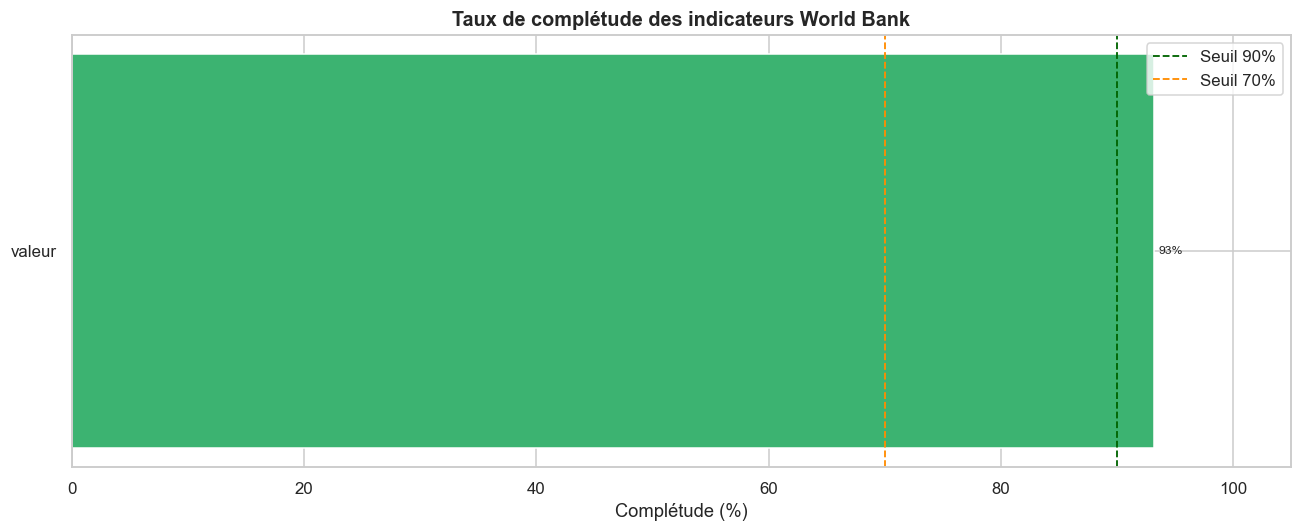

In [75]:
# Identifier les colonnes numériques (indicateurs économiques)
wb_num_cols = wb.select_dtypes(include="number").columns.tolist()
# Exclure l'index si présent
wb_num_cols = [c for c in wb_num_cols if c.lower() not in ["unnamed: 0", "index"]]

# Taux de complétude par indicateur
completeness = (wb[wb_num_cols].notna().mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(12, max(5, len(wb_num_cols) * 0.4)))
colors = ["tomato" if v < 70 else ("orange" if v < 90 else "mediumseagreen")
          for v in completeness.values]
ax.barh(completeness.index, completeness.values, color=colors)
ax.axvline(90, color="darkgreen", linestyle="--", linewidth=1.2, label="Seuil 90%")
ax.axvline(70, color="darkorange", linestyle="--", linewidth=1.2, label="Seuil 70%")
ax.set_xlabel("Complétude (%)")
ax.set_title("Taux de complétude des indicateurs World Bank", fontweight="bold", fontsize=13)
ax.set_xlim(0, 105)
ax.bar_label(ax.containers[0], fmt="%.0f%%", padding=3, fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

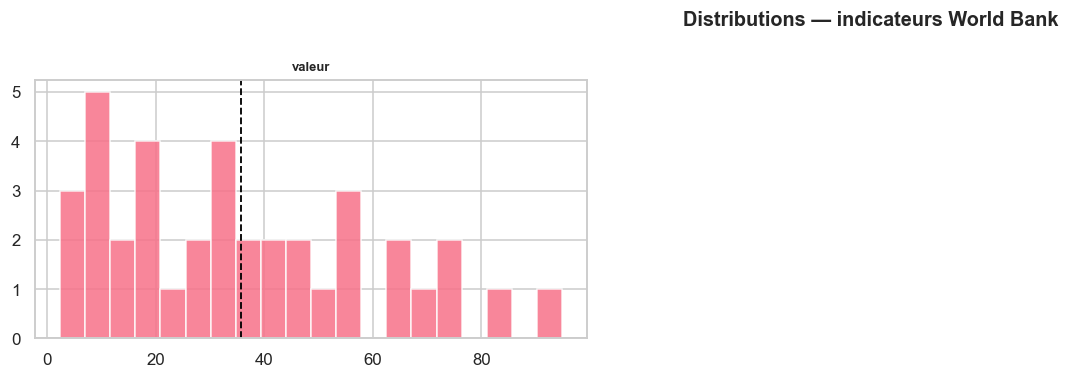

In [76]:
# Distributions des indicateurs World Bank les plus complets
top_cols = completeness[completeness >= 70].index.tolist()
if top_cols:
    # Dédupliquer par code_3L (garder une ligne par pays)
    wb_uniq = wb.drop_duplicates(subset="code_3L", keep="first") if "code_3L" in wb.columns else wb

    n = min(len(top_cols), 9)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    palette = sns.color_palette("husl", n)

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
    axes = axes.flatten()
    for i, (col, color) in enumerate(zip(top_cols[:n], palette)):
        data = pd.to_numeric(wb_uniq[col], errors="coerce").dropna()
        axes[i].hist(data, bins=20, color=color, edgecolor="white", alpha=0.85)
        axes[i].axvline(data.mean(), color="black", linestyle="--", linewidth=1.2)
        short = col if len(col) <= 30 else col[:28] + "..."
        axes[i].set_title(short, fontsize=8.5, fontweight="bold")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Distributions — indicateurs World Bank", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Aucune colonne avec ≥70% de complétude.")

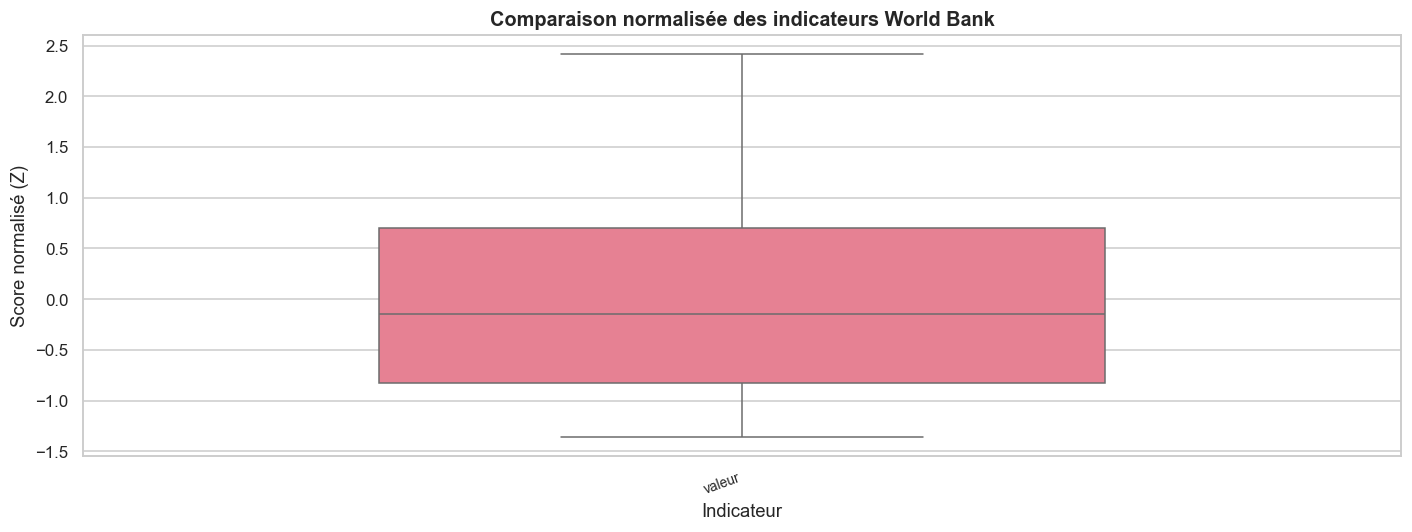

In [100]:
# Box plots comparatifs des indicateurs World Bank (top 6)
if len(top_cols) >= 1:
    wb_uniq = wb.drop_duplicates(subset="code_3L", keep="first") if "code_3L" in wb.columns else wb
    sel = top_cols[:6]
    wb_long = wb_uniq[sel].apply(pd.to_numeric, errors="coerce").melt(
        var_name="Indicateur", value_name="Valeur"
    ).dropna()

    # Normalisation Z-score pour comparaison
    from sklearn.preprocessing import StandardScaler
    wb_long["Valeur_norm"] = wb_long.groupby("Indicateur")["Valeur"].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-9)
    )

    fig, ax = plt.subplots(figsize=(13, 5))
    sns.boxplot(
        data=wb_long, x="Indicateur", y="Valeur_norm",
        palette="husl", width=0.55, flierprops=dict(marker=".", markersize=3),
        ax=ax,
    )
    ax.set_xticklabels(
        [c[:25] + "..." if len(c) > 28 else c for c in sel],
        rotation=20, ha="right", fontsize=9,
    )
    ax.set_ylabel("Score normalisé (Z)")
    ax.set_title("Comparaison normalisée des indicateurs World Bank", fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.show()

## 8 — Dataset ML Principal (data_clean)

In [78]:
print("Shape data_clean:", clean.shape)
clean.head(2)

Shape data_clean: (1008, 39)


,Unnamed: 0,month,temp_avg,temp_max,temp_min,region,short_description,latitude,longitude,Services voyage (% exports de services),...,Recettes voyages touristiques (USD),Dépenses tourisme (USD),city,nature,patrimoine,culture,restaurant,nightlife,loisirs,country
0,0,1,28.7,33.3,25.8,africa,"Lively streets filled with vibrant markets, rh...",5.55711,-0.201238,11.966207,...,110000000.0,946000000.0,Accra,0.04,0.88,0.15,0.36,0.99,0.69,ghana
1,22,10,27.3,31.1,24.4,africa,"Lively streets filled with vibrant markets, rh...",5.55711,-0.201238,11.966207,...,110000000.0,946000000.0,Accra,0.04,0.88,0.15,0.36,0.99,0.69,ghana


In [79]:
# Colonnes activités dans data_clean
ACT_CLEAN = [c for c in ["nature", "patrimoine", "culture", "restaurant", "nightlife", "loisirs"]
             if c in clean.columns]
TEMP_COLS = [c for c in ["temp_avg", "temp_max", "temp_min"] if c in clean.columns]
print("Activités:", ACT_CLEAN)
print("Températures:", TEMP_COLS)

# Sélectionner colonnes numériques pour corrélation
num_clean = clean.select_dtypes(include="number").drop(
    columns=[c for c in ["Unnamed: 0", "index", "month"] if c in clean.columns],
    errors="ignore",
)
# Garder seulement colonnes avec >50% de données
num_clean = num_clean.loc[:, num_clean.notna().mean() > 0.5]
print(f"\n{num_clean.shape[1]} colonnes numériques retenues pour corrélation")

Activités: ['nature', 'patrimoine', 'culture', 'restaurant', 'nightlife', 'loisirs']
Températures: ['temp_avg', 'temp_max', 'temp_min']

33 colonnes numériques retenues pour corrélation


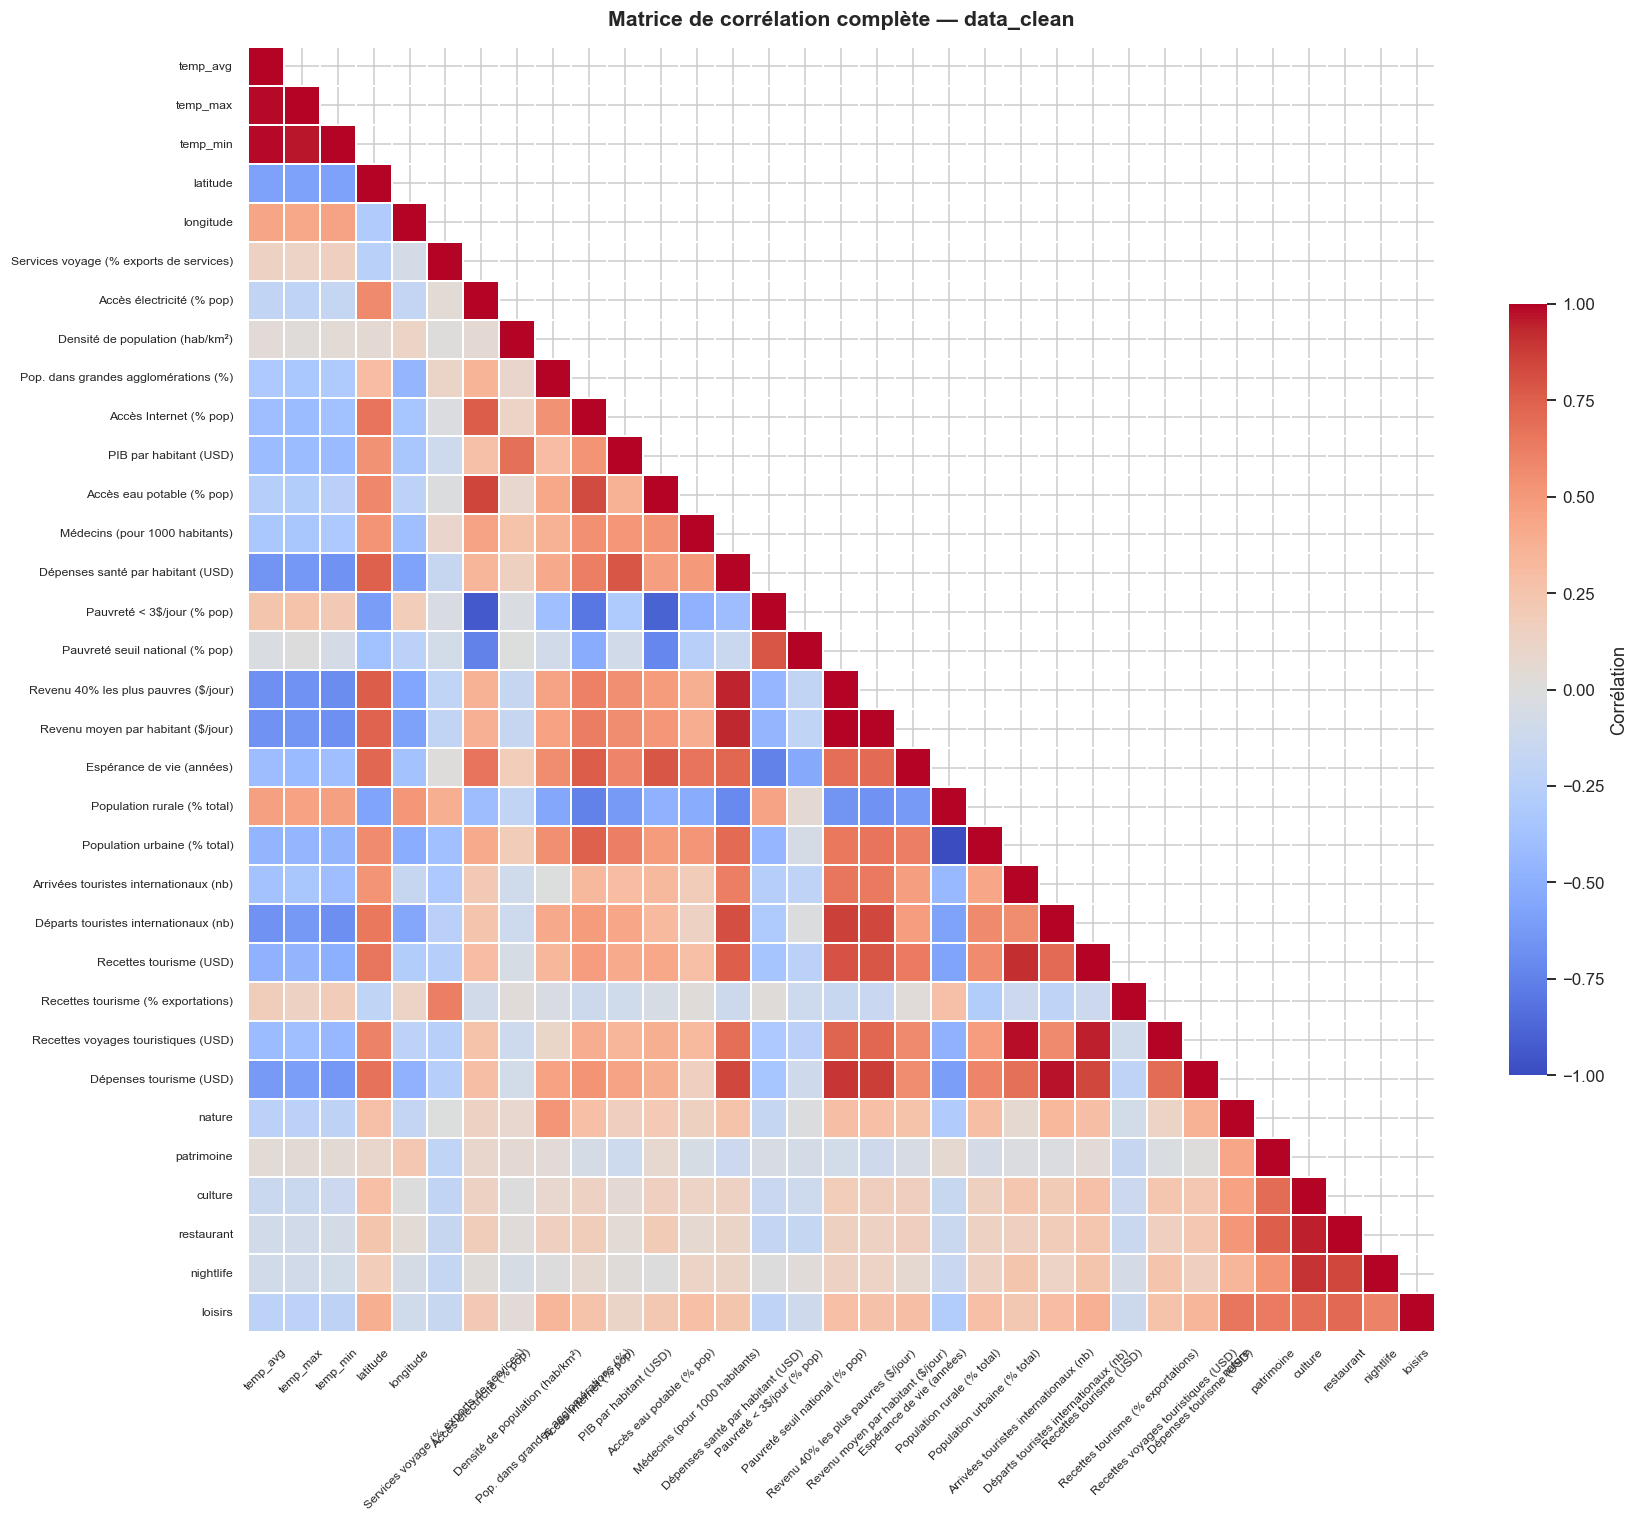

In [80]:
# Matrice de corrélation complète — data_clean
corr_clean = num_clean.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_clean, dtype=bool), k=1)
sns.heatmap(
    corr_clean, mask=mask,
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    xticklabels=corr_clean.columns, yticklabels=corr_clean.columns,
    linewidths=0.2, annot=False,
    cbar_kws={"shrink": 0.6, "label": "Corrélation"},
    ax=ax,
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
ax.set_title("Matrice de corrélation complète — data_clean",
             fontweight="bold", fontsize=14, pad=14)
plt.tight_layout()
plt.show()

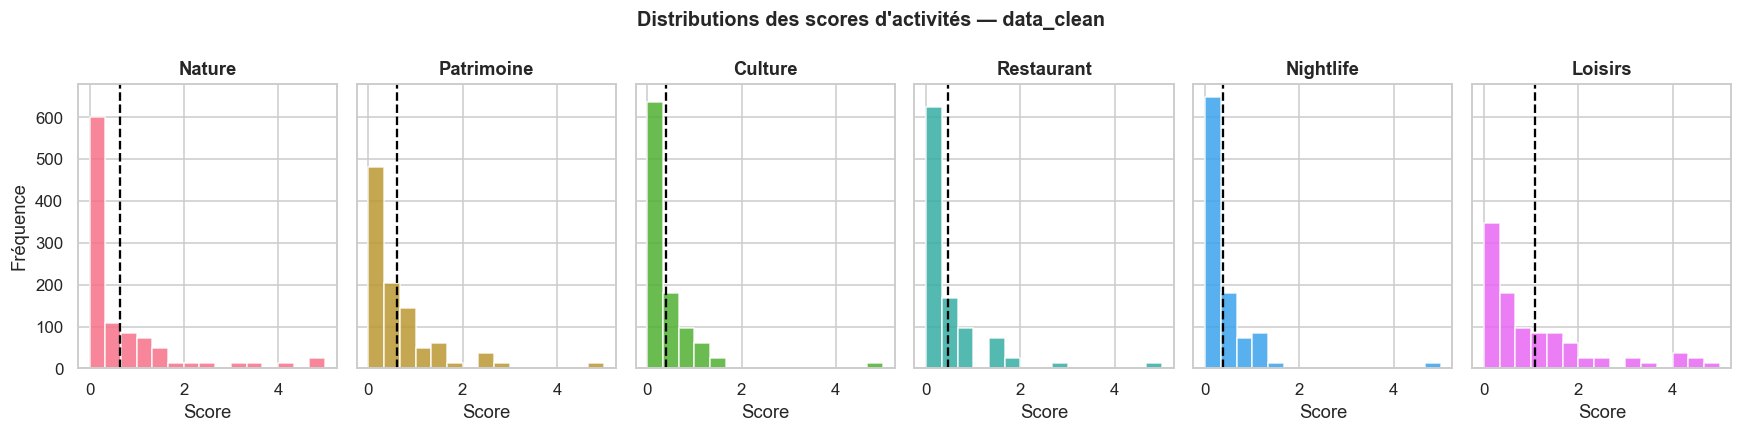

In [81]:
# Distributions des scores d'activités dans data_clean
if ACT_CLEAN:
    fig, axes = plt.subplots(1, len(ACT_CLEAN), figsize=(16, 4), sharey=True)
    if len(ACT_CLEAN) == 1:
        axes = [axes]
    palette = sns.color_palette("husl", len(ACT_CLEAN))
    for ax, col, color in zip(axes, ACT_CLEAN, palette):
        ax.hist(clean[col].dropna(), bins=15, color=color, edgecolor="white", alpha=0.85)
        ax.axvline(clean[col].mean(), color="black", linestyle="--", linewidth=1.5)
        ax.set_title(col.capitalize(), fontweight="bold")
        ax.set_xlabel("Score")
    axes[0].set_ylabel("Fréquence")
    plt.suptitle("Distributions des scores d'activités — data_clean", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

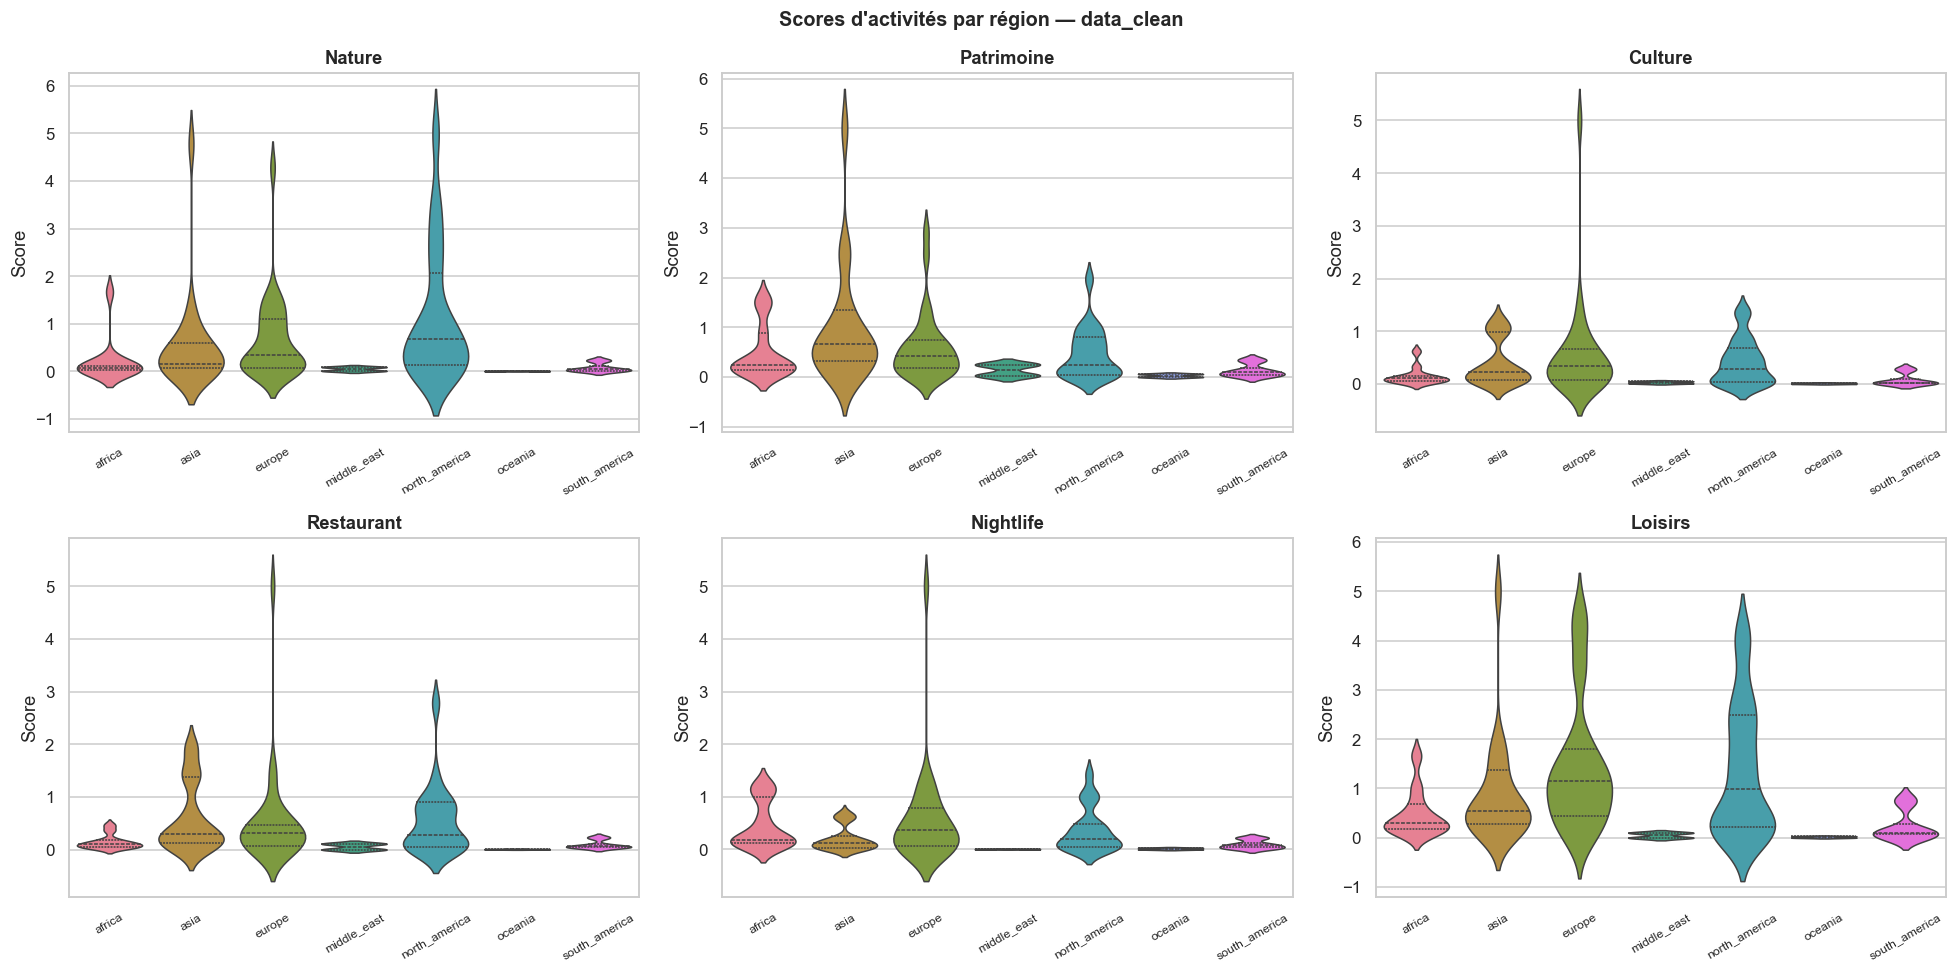

In [82]:
# Violin plots des activités par région
if ACT_CLEAN and "region" in clean.columns:
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    axes = axes.flatten()
    regions_clean = sorted(clean["region"].dropna().unique())
    palette = sns.color_palette("husl", len(regions_clean))

    for i, (ax, col) in enumerate(zip(axes, ACT_CLEAN)):
        sns.violinplot(
            data=clean, x="region", y=col,
            order=regions_clean, palette=palette,
            inner="quartile", linewidth=1, ax=ax,
        )
        ax.set_xlabel("")
        ax.set_title(col.capitalize(), fontweight="bold")
        ax.tick_params(axis="x", rotation=30, labelsize=8)
        ax.set_ylabel("Score")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Scores d'activités par région — data_clean", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

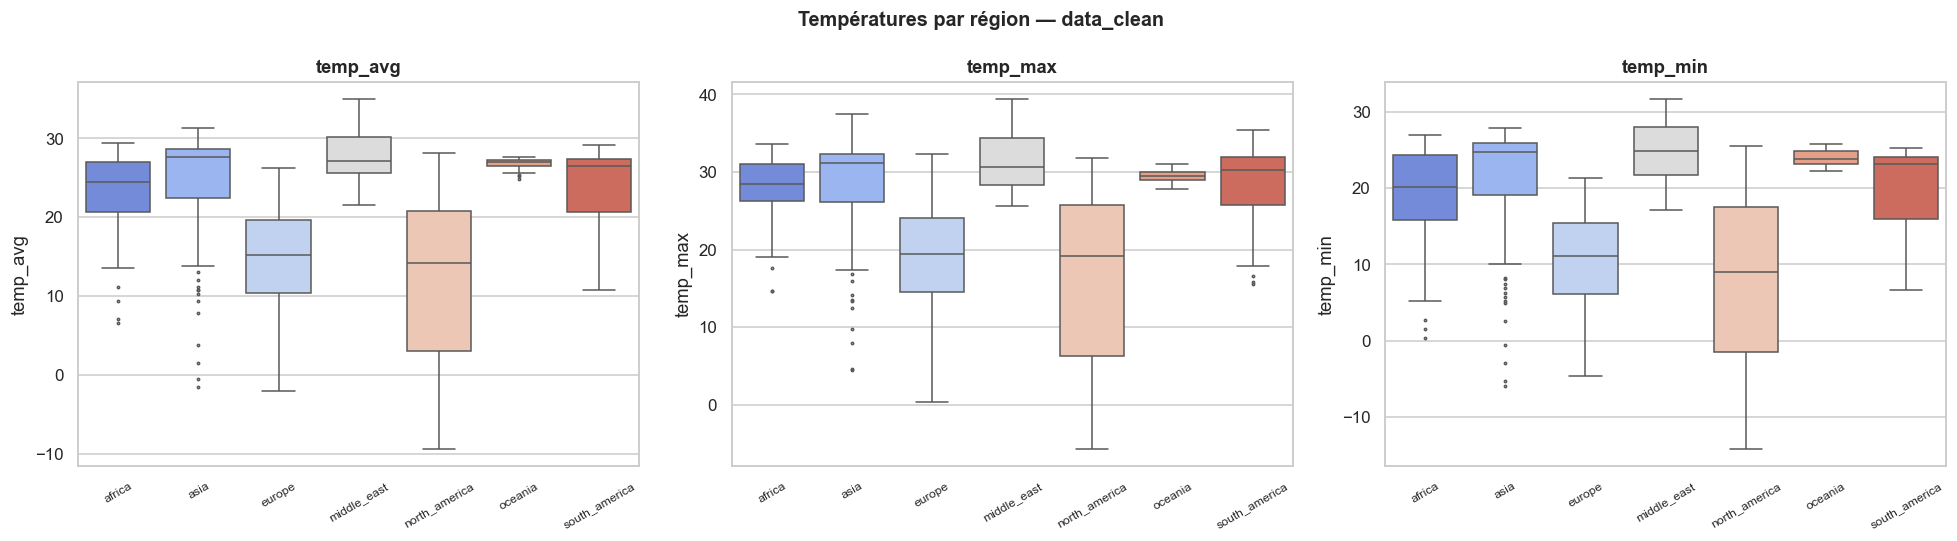

In [83]:
# Températures par région (data_clean)
if "region" in clean.columns and "temp_avg" in clean.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, col in zip(axes, TEMP_COLS):
        sns.boxplot(
            data=clean, x="region", y=col,
            palette="coolwarm",
            order=sorted(clean["region"].dropna().unique()),
            flierprops=dict(marker=".", markersize=3), ax=ax,
        )
        ax.set_title(col, fontweight="bold")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30, labelsize=8)
    plt.suptitle("Températures par région — data_clean", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 9 — Travel Destinations (raw)

In [84]:
print("Colonnes travel_destinations.csv:")
print(raw.dtypes.to_string())
raw.head(3)

Colonnes travel_destinations.csv:
City                   object
Country                object
Category               object
Best_Time_to_Travel    object


,City,Country,Category,Best_Time_to_Travel
0,London,United Kingdom,"history, culture, museums, theatre, shopping, ...","Apr, May, Jun, Sep, Oct"
1,Paris,France,"art, museums, landmarks, culture, history, foo...","Apr, May, Jun, Sep, Oct"
2,Rome,Italy,"history, ancient ruins, culture, art, food, re...","Apr, May, Jun, Sep, Oct"


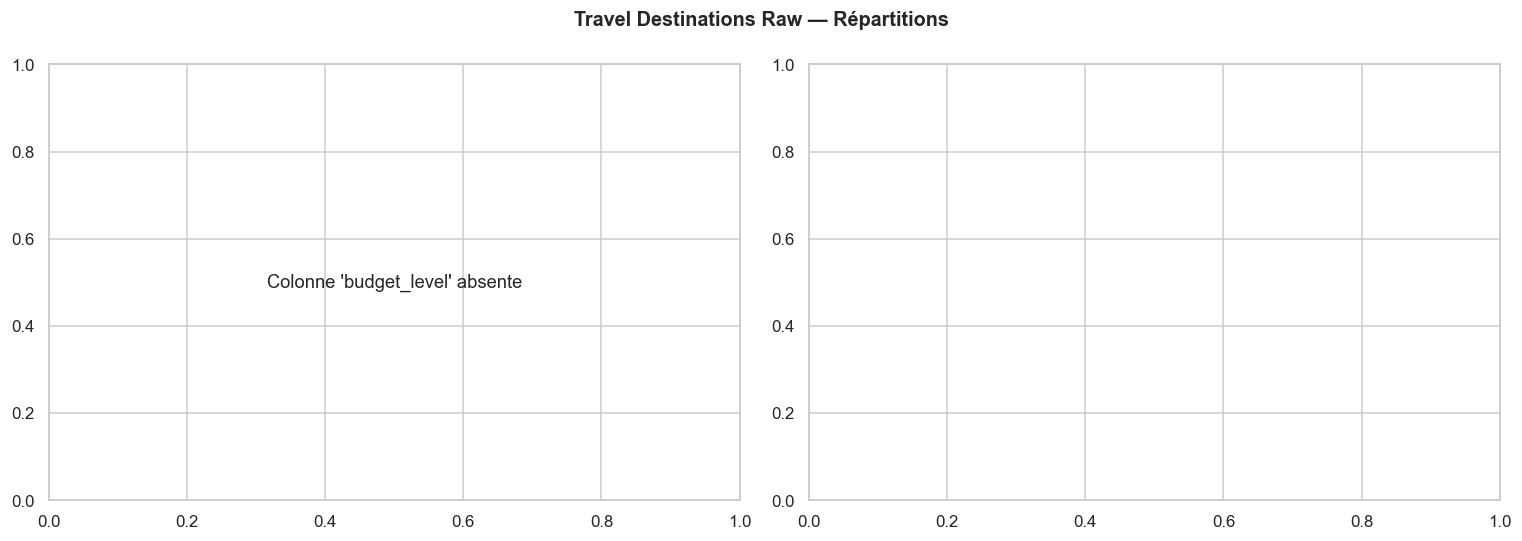

In [85]:
# Identifier colonnes d'activités dans le fichier raw
RAW_ACT = [c for c in ["culture", "adventure", "nature", "beaches",
                        "nightlife", "cuisine", "wellness", "urban", "seclusion"]
           if c in raw.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie : budget_level
if "budget_level" in raw.columns:
    budget_counts = raw["budget_level"].value_counts()
    axes[0].pie(
        budget_counts.values,
        labels=budget_counts.index,
        autopct="%1.1f%%",
        colors=sns.color_palette("Set2", len(budget_counts)),
        startangle=90,
        wedgeprops=dict(linewidth=1.5, edgecolor="white"),
        pctdistance=0.75,
    )
    axes[0].set_title("Répartition par niveau de budget", fontweight="bold")
else:
    axes[0].text(0.5, 0.5, "Colonne 'budget_level' absente",
                 ha="center", va="center", transform=axes[0].transAxes)

# Pie : region
if "region" in raw.columns:
    reg_counts = raw["region"].value_counts()
    axes[1].pie(
        reg_counts.values,
        labels=reg_counts.index,
        autopct="%1.1f%%",
        colors=sns.color_palette("husl", len(reg_counts)),
        startangle=140,
        wedgeprops=dict(linewidth=1.5, edgecolor="white"),
        pctdistance=0.78,
    )
    axes[1].set_title("Répartition par région", fontweight="bold")

plt.suptitle("Travel Destinations Raw — Répartitions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [86]:
# Activités par niveau de budget (grouped box plots)
if RAW_ACT and "budget_level" in raw.columns:
    raw_long = raw[["budget_level"] + RAW_ACT].melt(
        id_vars="budget_level", var_name="Activité", value_name="Score"
    ).dropna()

    fig, ax = plt.subplots(figsize=(15, 5))
    sns.boxplot(
        data=raw_long, x="Activité", y="Score", hue="budget_level",
        palette="Set2", width=0.65, ax=ax,
        flierprops=dict(marker=".", markersize=3),
    )
    ax.set_ylabel("Score (1–5)")
    ax.set_title("Scores d'activités selon le niveau de budget", fontweight="bold", fontsize=13)
    ax.legend(title="Budget", loc="lower right")
    plt.tight_layout()
    plt.show()

In [87]:
# Score moyen par activité et par budget (heatmap)
if RAW_ACT and "budget_level" in raw.columns:
    pivot_budget = raw.groupby("budget_level")[RAW_ACT].mean()

    fig, ax = plt.subplots(figsize=(11, 3.5))
    sns.heatmap(
        pivot_budget, cmap="YlOrRd",
        annot=True, fmt=".1f", annot_kws={"size": 10},
        linewidths=0.5, cbar_kws={"label": "Score moyen"},
        ax=ax,
    )
    ax.set_title("Score moyen par activité × budget", fontweight="bold", fontsize=12)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## 10 — Données Touristes (donnees_touriste.csv)

In [88]:
print("Colonnes touriste:", tour.columns.tolist())
tour

Colonnes touriste: ['pays', 'Services voyage (% exports de services)', 'Accès électricité (% pop)', 'Densité de population (hab/km²)', 'Pop. dans grandes agglomérations (%)', 'Accès Internet (% pop)', 'PIB par habitant (USD)', 'Accès eau potable (% pop)', 'Médecins (pour 1000 habitants)', 'Dépenses santé par habitant (USD)', 'Pauvreté < 3$/jour (% pop)', 'Pauvreté seuil national (% pop)', 'Revenu 40% les plus pauvres ($/jour)', 'Revenu moyen par habitant ($/jour)', 'Espérance de vie (années)', 'Population rurale (% total)', 'Population urbaine (% total)', 'Arrivées touristes internationaux (nb)', 'Départs touristes internationaux (nb)', 'Recettes tourisme (USD)', 'Recettes tourisme (% exportations)', 'Recettes voyages touristiques (USD)', 'Dépenses tourisme (USD)', 'date_maj']


,pays,Services voyage (% exports de services),Accès électricité (% pop),Densité de population (hab/km²),Pop. dans grandes agglomérations (%),Accès Internet (% pop),PIB par habitant (USD),Accès eau potable (% pop),Médecins (pour 1000 habitants),Dépenses santé par habitant (USD),...,Espérance de vie (années),Population rurale (% total),Population urbaine (% total),Arrivées touristes internationaux (nb),Départs touristes internationaux (nb),Recettes tourisme (USD),Recettes tourisme (% exportations),Recettes voyages touristiques (USD),Dépenses tourisme (USD),date_maj
0,AGO,9.923331,51.1,29.477746,25.285333,44.7581,2916.136633,67.224425,0.244,76.071182,...,64.617000,30.148497,69.851503,2.180000e+05,NaN,1.900000e+07,0.090457,1.600000e+07,6.910000e+08,2026-03-26
1,BDI,2.372476,11.6,533.078271,NaN,11.0784,250.627253,65.806988,0.078,28.140289,...,63.651000,76.446523,23.553477,2.990000e+05,NaN,3.700000e+06,1.570029,3.900000e+06,4.900000e+07,2026-03-26
2,BGD,7.113293,99.5,1319.179797,16.673341,44.5027,2551.017738,98.681668,0.722,53.464325,...,74.672000,67.842153,32.157847,3.230000e+05,1.460000e+06,2.179000e+08,0.566327,2.170000e+08,6.590000e+08,2026-03-26
3,BWA,69.432982,76.0,4.376412,NaN,81.3600,7826.353765,91.723655,0.379,489.596771,...,69.163000,32.978734,67.021266,1.830000e+06,NaN,2.170000e+08,4.561363,2.110000e+08,9.180000e+07,2026-03-26
4,CAN,29.408235,100.0,4.560798,44.802126,93.9564,54220.328504,98.290504,2.819,6186.652344,...,81.646585,17.474944,82.525056,3.243000e+07,3.784590e+07,1.999400e+10,3.656701,1.125600e+10,4.124700e+10,2026-03-26
5,CRI,32.223524,100.0,99.990697,28.635429,85.3951,16942.026812,99.814304,2.687,1163.302246,...,80.799000,21.118061,78.881939,1.146500e+06,3.240000e+05,1.479000e+09,7.405314,1.356000e+09,6.970000e+08,2026-03-26
6,CUB,NaN,100.0,106.165039,19.500394,71.2750,9605.279146,95.023635,9.542,1199.353271,...,78.085000,22.874013,77.125987,1.086000e+06,2.710000e+05,1.152000e+09,NaN,1.137000e+09,NaN,2026-03-26
7,FRA,19.041465,100.0,126.862021,22.927853,86.8364,44700.138418,100.000000,3.281,5149.054688,...,82.929268,21.219568,78.780432,1.171090e+08,2.128700e+07,3.595800e+10,4.804042,3.264600e+10,3.119300e+10,2026-03-26
8,GAB,9.070292,94.1,9.643300,NaN,71.9256,7802.824333,88.479261,0.521,252.982468,...,68.337000,8.362404,91.637596,NaN,NaN,2.870000e+07,0.532472,2.500000e+07,3.460000e+08,2026-03-26
9,GHA,11.966207,89.5,148.496763,19.025475,69.9445,2383.904105,88.891050,0.266,70.257309,...,65.498000,42.192526,57.807474,8.970000e+05,NaN,1.910000e+08,0.865151,1.100000e+08,9.460000e+08,2026-03-26


In [89]:
# Catégories : fréquence des mots-clés
if "Category" in tour.columns:
    # Exploser les catégories (séparées par /)
    cats = tour["Category"].dropna().str.split("/").explode().str.strip()
    cat_counts = cats.value_counts().head(20)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(cat_counts.index[::-1], cat_counts.values[::-1],
            color=sns.color_palette("husl", len(cat_counts)))
    ax.set_xlabel("Nombre de destinations")
    ax.set_title("Top 20 catégories de destinations touristiques", fontweight="bold", fontsize=13)
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)
    plt.tight_layout()
    plt.show()

In [90]:
# Best Time to Travel — heatmap (villes × mois)
if "Best_Time_to_Travel" in tour.columns and "City" in tour.columns:
    MOIS_ABBR = {"January": "Jan", "February": "Fév", "March": "Mar",
                 "April": "Avr", "May": "Mai", "June": "Jun",
                 "July": "Jul", "August": "Aoû", "September": "Sep",
                 "October": "Oct", "November": "Nov", "December": "Déc"}
    ALL_MONTHS = list(MOIS_ABBR.values())

    rows = []
    for _, row in tour.iterrows():
        months = str(row["Best_Time_to_Travel"]).replace("and", ",").split(",")
        for m in months:
            mstrip = m.strip()
            for full, abbr in MOIS_ABBR.items():
                if full.lower() in mstrip.lower():
                    rows.append({"City": row["City"], "Mois": abbr})

    df_travel_time = pd.DataFrame(rows)
    if not df_travel_time.empty:
        pivot_tt = df_travel_time.groupby(["City", "Mois"]).size().unstack(fill_value=0)
        pivot_tt = pivot_tt.reindex(columns=[m for m in ALL_MONTHS if m in pivot_tt.columns])

        fig, ax = plt.subplots(figsize=(13, max(5, len(pivot_tt) * 0.5)))
        sns.heatmap(
            pivot_tt, cmap="YlGn",
            linewidths=0.5, annot=True, fmt="d",
            annot_kws={"size": 8}, cbar=False, ax=ax,
        )
        ax.set_title("Meilleure période de voyage par destination",
                     fontweight="bold", fontsize=13)
        ax.set_xlabel("")
        ax.set_ylabel("")
        plt.tight_layout()
        plt.show()
    else:
        print("Pas de données de mois parsables.")

## 11 — Villes Mondiales (villes.csv)

In [91]:
print("Shape villes:", villes.shape)
villes.head(3)

Shape villes: (5986, 10)


,Unnamed: 0,geonameid,name,asciiname,latitude,longitude,feature_code,country_code,population,timezone
0,20,290503,Warīsān,Warisan,25.16744,55.40708,PPL,AE,108759,Asia/Dubai
1,25,291074,Ras Al Khaimah,Ras Al Khaimah,25.78953,55.94320,PPLA,AE,351943,Asia/Dubai
2,34,292223,Dubai,Dubai,25.07725,55.30927,PPLA,AE,3790000,Asia/Dubai


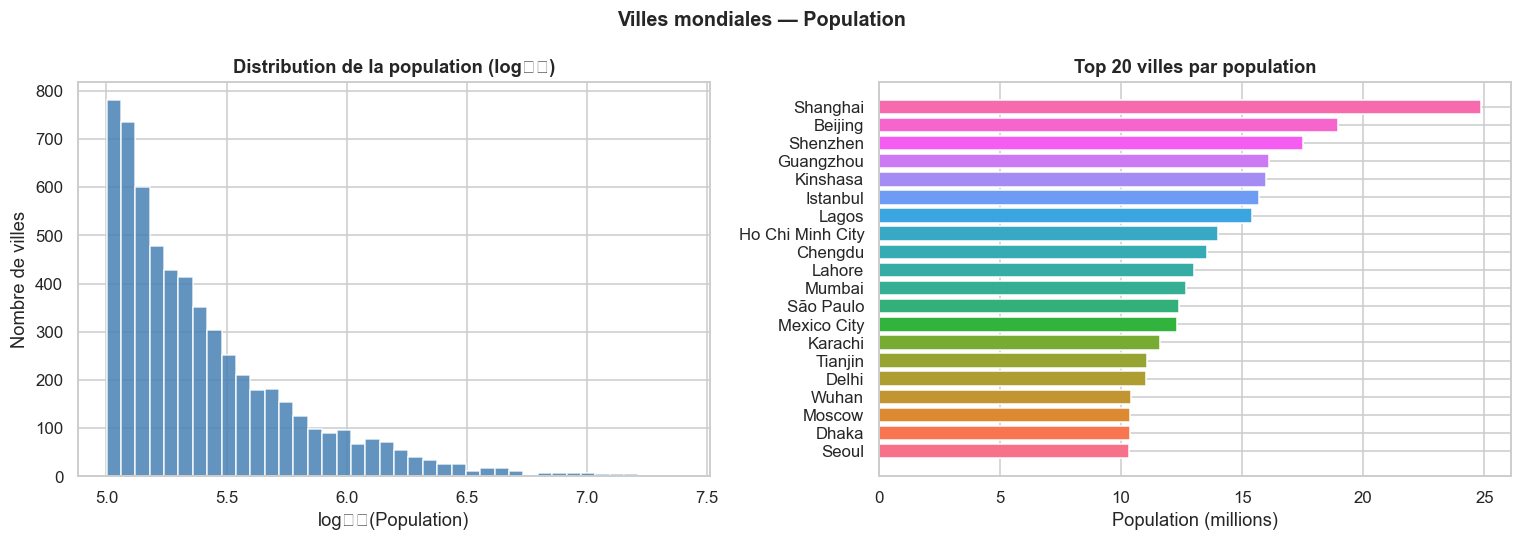

In [92]:
# Distribution des populations (log scale)
pop_col = "population" if "population" in villes.columns else None
if pop_col:
    pop_data = villes[pop_col].dropna()
    pop_data = pop_data[pop_data > 0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(np.log10(pop_data + 1), bins=40, color="steelblue",
                 edgecolor="white", alpha=0.85)
    axes[0].set_xlabel("log₁₀(Population)")
    axes[0].set_ylabel("Nombre de villes")
    axes[0].set_title("Distribution de la population (log₁₀)", fontweight="bold")

    # Top 20 villes par population
    name_col = "name" if "name" in villes.columns else villes.columns[0]
    top_villes = villes.nlargest(20, pop_col)[[name_col, pop_col]].set_index(name_col)
    axes[1].barh(top_villes.index[::-1], top_villes[pop_col][::-1] / 1e6,
                 color=sns.color_palette("husl", 20))
    axes[1].set_xlabel("Population (millions)")
    axes[1].set_title("Top 20 villes par population", fontweight="bold")

    plt.suptitle("Villes mondiales — Population", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

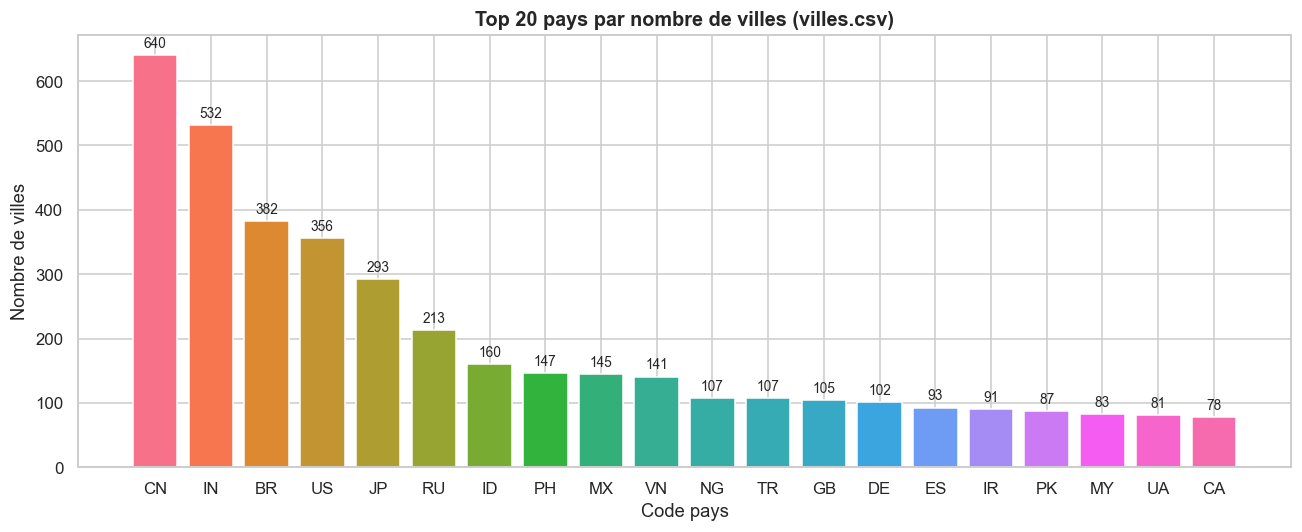

In [93]:
# Distribution par pays (top 20)
cc_col = "country_code" if "country_code" in villes.columns else None
if cc_col:
    top_cc = villes[cc_col].value_counts().head(20)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(top_cc.index, top_cc.values, color=sns.color_palette("husl", 20))
    ax.set_xlabel("Code pays")
    ax.set_ylabel("Nombre de villes")
    ax.set_title("Top 20 pays par nombre de villes (villes.csv)", fontweight="bold", fontsize=13)
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)
    plt.tight_layout()
    plt.show()

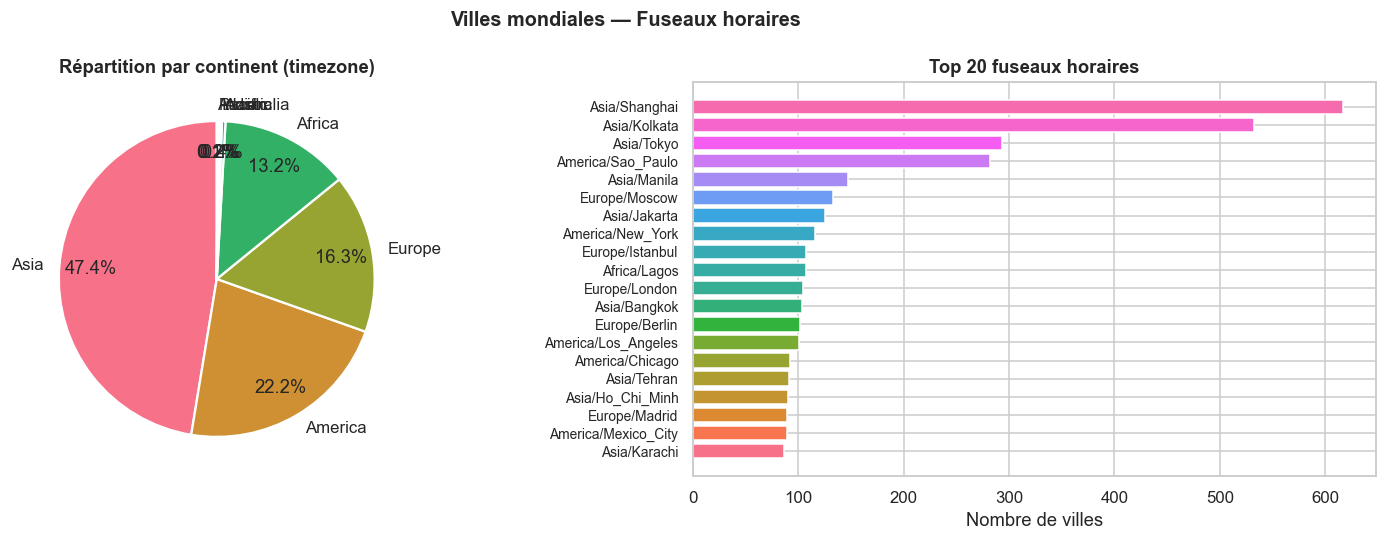

In [94]:
# Distribution des fuseaux horaires
tz_col = "timezone" if "timezone" in villes.columns else None
if tz_col:
    # Extraire le continent du timezone (Europe/Paris → Europe)
    villes["tz_continent"] = villes[tz_col].str.split("/").str[0]
    tz_cont = villes["tz_continent"].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].pie(
        tz_cont.values,
        labels=tz_cont.index,
        autopct="%1.1f%%",
        colors=sns.color_palette("husl", len(tz_cont)),
        startangle=90,
        wedgeprops=dict(linewidth=1.5, edgecolor="white"),
        pctdistance=0.8,
    )
    axes[0].set_title("Répartition par continent (timezone)", fontweight="bold")

    # Top 20 timezones
    top_tz = villes[tz_col].value_counts().head(20)
    axes[1].barh(top_tz.index[::-1], top_tz.values[::-1],
                 color=sns.color_palette("husl", 20))
    axes[1].set_xlabel("Nombre de villes")
    axes[1].set_title("Top 20 fuseaux horaires", fontweight="bold")
    axes[1].tick_params(axis="y", labelsize=9)

    plt.suptitle("Villes mondiales — Fuseaux horaires", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 12 — Features ML (df_ml.csv)

In [95]:
print("Shape df_ml:", ml.shape)
ml.head(3)

Shape df_ml: (560, 54)


,Unnamed: 0,latitude,longitude,budget_level,culture,adventure,nature,beaches,nightlife,cuisine,...,temp_month9_min,temp_month10_avg,temp_month10_max,temp_month10_min,temp_month11_avg,temp_month11_max,temp_month11_min,temp_month12_avg,temp_month12_max,temp_month12_min
0,0,45.464194,9.189635,3,5,2,2,1,4,5,...,16.1,15.2,19.6,11.5,8.8,12.5,5.6,4.7,8.2,1.9
1,1,-17.290947,177.125786,3,2,4,5,5,2,3,...,24.5,26.0,30.5,19.0,27.1,31.0,24.8,28.2,31.9,26.0
2,2,50.117190,-122.954302,3,3,5,5,2,3,3,...,9.9,7.6,11.6,4.4,1.8,5.1,-1.6,-1.8,0.9,-2.5


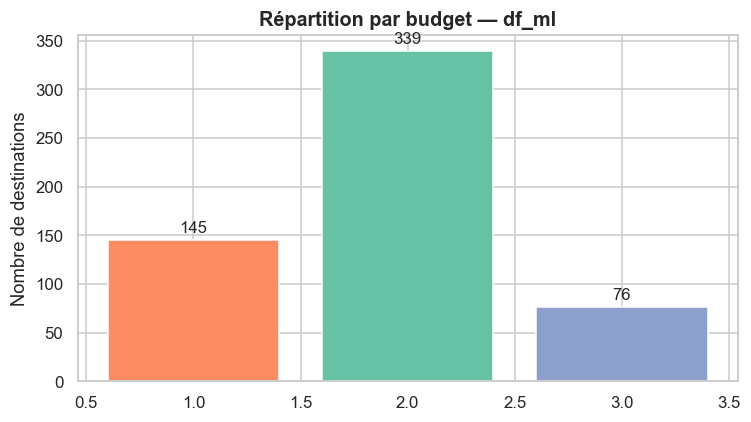

In [96]:
# Budget distribution dans df_ml
if "budget_level" in ml.columns:
    budget_ml = ml["budget_level"].value_counts()

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(budget_ml.index, budget_ml.values,
                  color=sns.color_palette("Set2", len(budget_ml)))
    ax.bar_label(bars, padding=3, fontsize=11)
    ax.set_ylabel("Nombre de destinations")
    ax.set_title("Répartition par budget — df_ml", fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.show()

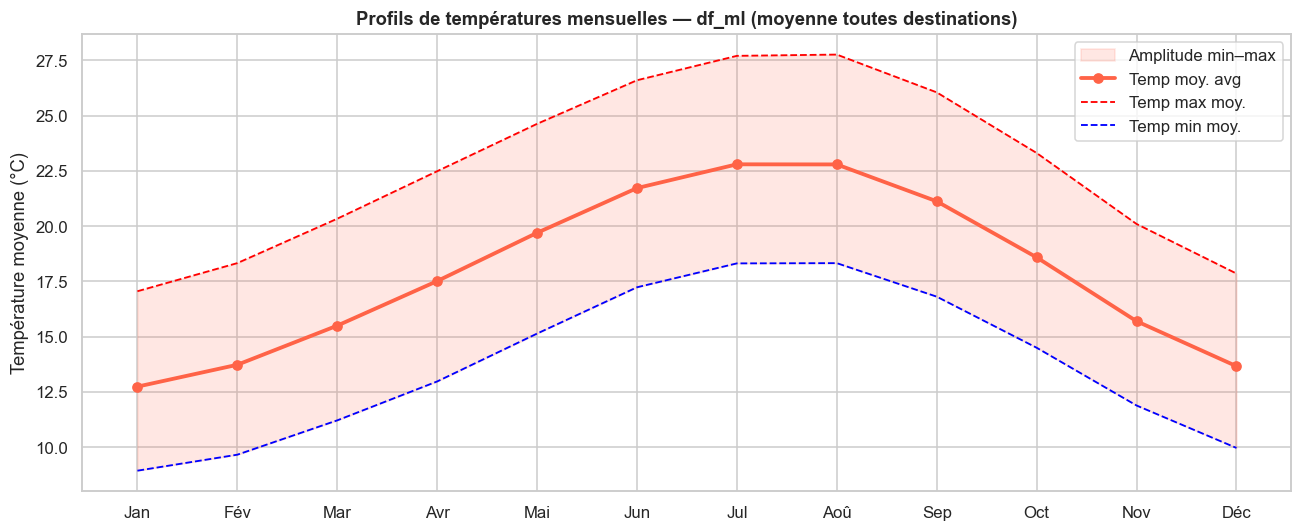

In [97]:
# Colonnes de température mensuelle dans df_ml
temp_avg_cols = [c for c in ml.columns if "temp_month" in c and "_avg" in c]
temp_max_cols = [c for c in ml.columns if "temp_month" in c and "_max" in c]
temp_min_cols = [c for c in ml.columns if "temp_month" in c and "_min" in c]

if temp_avg_cols:
    avg_by_month = ml[temp_avg_cols].mean()
    max_by_month = ml[temp_max_cols].mean() if temp_max_cols else None
    min_by_month = ml[temp_min_cols].mean() if temp_min_cols else None

    months = list(range(1, len(temp_avg_cols) + 1))
    month_labels = ["Jan","Fév","Mar","Avr","Mai","Jun",
                    "Jul","Aoû","Sep","Oct","Nov","Déc"][:len(months)]

    fig, ax = plt.subplots(figsize=(12, 5))
    if max_by_month is not None and min_by_month is not None:
        ax.fill_between(months, min_by_month.values, max_by_month.values,
                        alpha=0.15, color="tomato", label="Amplitude min–max")
    ax.plot(months, avg_by_month.values, color="tomato", marker="o",
            linewidth=2.5, label="Temp moy. avg")
    if max_by_month is not None:
        ax.plot(months, max_by_month.values, "r--", linewidth=1.2, label="Temp max moy.")
    if min_by_month is not None:
        ax.plot(months, min_by_month.values, "b--", linewidth=1.2, label="Temp min moy.")
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)
    ax.set_ylabel("Température moyenne (°C)")
    ax.set_title("Profils de températures mensuelles — df_ml (moyenne toutes destinations)",
                 fontweight="bold", fontsize=12)
    ax.legend()
    plt.tight_layout()
    plt.show()

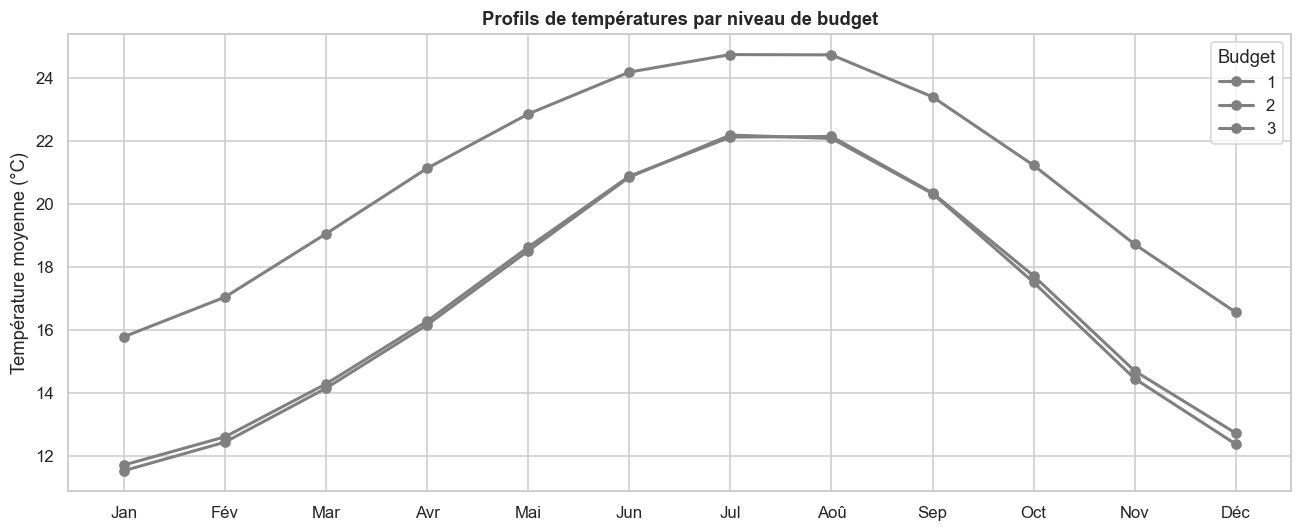

In [98]:
# Températures mensuelles moyennes par budget
if temp_avg_cols and "budget_level" in ml.columns:
    budget_temp = ml.groupby("budget_level")[temp_avg_cols].mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    colors_budget = {"Budget": "steelblue", "Mid-range": "mediumseagreen", "Luxury": "gold"}
    for btype in budget_temp.index:
        color = colors_budget.get(btype, "gray")
        ax.plot(months, budget_temp.loc[btype].values,
                marker="o", linewidth=2, label=btype, color=color)
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)
    ax.set_ylabel("Température moyenne (°C)")
    ax.set_title("Profils de températures par niveau de budget", fontweight="bold", fontsize=12)
    ax.legend(title="Budget")
    plt.tight_layout()
    plt.show()

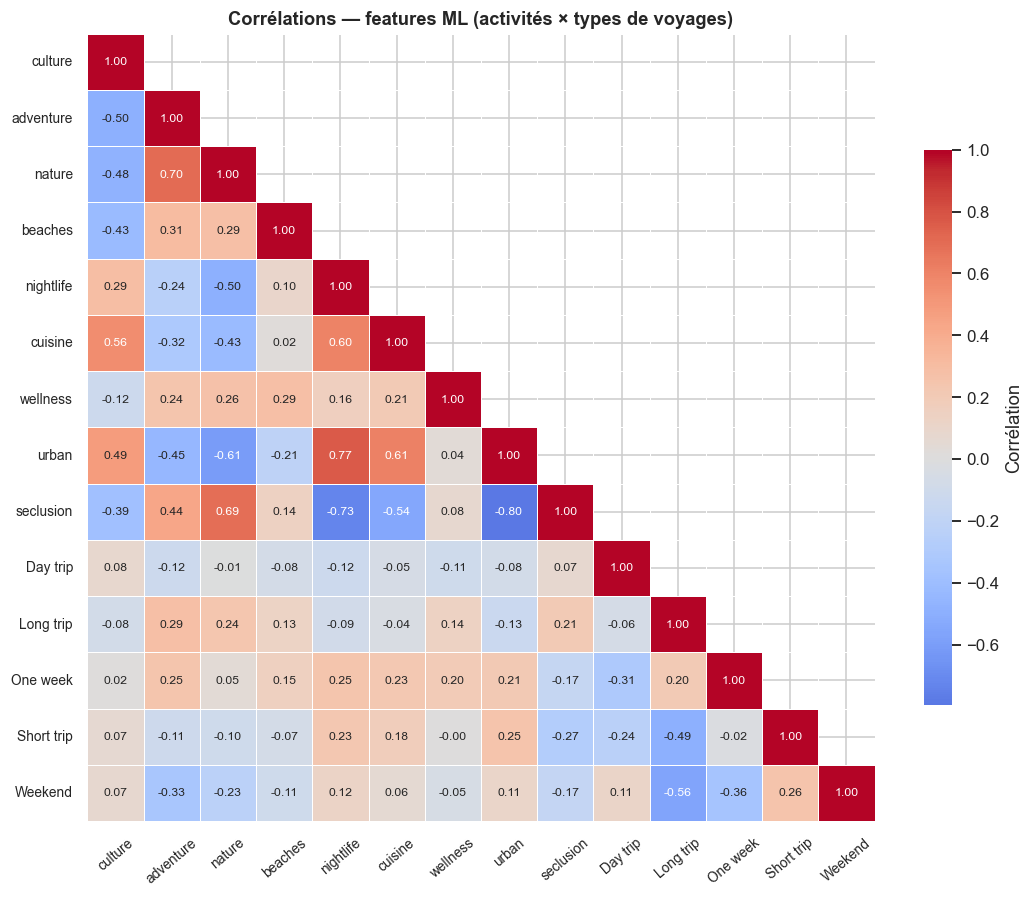

In [99]:
# Corrélation features ML (activités + types de voyages)
ML_ACT = [c for c in ["culture", "adventure", "nature", "beaches",
                       "nightlife", "cuisine", "wellness", "urban", "seclusion"]
          if c in ml.columns]
TRIP_COLS = [c for c in ml.columns if any(t in c.lower() for t in
             ["day trip", "long trip", "one week", "short trip", "weekend"])]

feature_cols = ML_ACT + TRIP_COLS
if len(feature_cols) >= 4:
    corr_ml = ml[feature_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 9))
    mask = np.triu(np.ones_like(corr_ml, dtype=bool), k=1)
    sns.heatmap(
        corr_ml, mask=mask,
        cmap="coolwarm", center=0,
        annot=True, fmt=".2f", annot_kws={"size": 8},
        linewidths=0.5, square=True,
        cbar_kws={"shrink": 0.6, "label": "Corrélation"},
        ax=ax,
    )
    ax.tick_params(axis="x", rotation=40, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.set_title("Corrélations — features ML (activités × types de voyages)",
                 fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.show()